<a href="https://colab.research.google.com/github/Misha-private/Demo-repo/blob/main/MGBF_hexa_v0.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Connect to /contend/drive

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


# test_graph_smoother_level0_v0.py

Build S = A^{-1} K

A = diagonal cell-area matrix
K = symmetric finite-support graph kernel

Then
S is self-adjoint under <x,y>_A
S conserves area-weighted mean
B = S S is positive semi-definite

We use symmetric Sinkhorn normalization so both properties hold.

Grid keys:
  cell_center_xyz (2562, 3) float64
  cell_center_lon (2562,) float64
  cell_center_lat (2562,) float64
  dual_vertex_xyz (5120, 3) float64
  dual_vertex_lon (5120,) float64
  dual_vertex_lat (5120,) float64
  cell_area (2562,) float64
  primal_faces (5120, 3) int64
  dual_cells (2562,) object

Number of cells: 2562
Area min/max: 134536555820.17395 238195365847.2499
Total area: 510099699070761.6

Neighbor degree min/max: 5 6
Degree counts: {np.int64(5): 12, np.int64(6): 2550}

K0 nnz: 94422
K0 symmetry error: 0.0
Sinkhorn iter    0: max ratio error = 2.455e+10
Sinkhorn converged at iter 41: error = 9.970e-14

K nnz: 94422
K row-sum/area max relative error: 3.433382122534929e-14
K symmetry error: 3.814697265625e-06

LEVEL-0 GRAPH SMOOTHER TESTS

Self-adjointness of S:
  <x, S y>_A = -4465007528911.149
  <S x, y>_A = -4465007528911.15
  relative error = 2.1871463680110465e-16

Area-mean conservation:
  mean_A(x)  = -0.01077424144012687
  mean_A(Sx) = -0.010774241440126897
  re

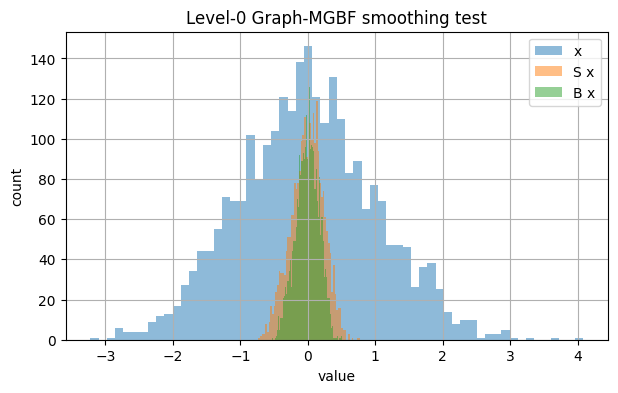

In [ ]:
import numpy as np
import scipy.sparse as sp
from collections import deque
import matplotlib.pyplot as plt

# ============================================================
# Configuration
# ============================================================

GRID_FILE = "/content/drive/MyDrive/GLOBAL_SW_FV/grid/global_hex_ico_grid_v0.npz"

R_SUPPORT = 3          # graph-ring support radius
SIGMA_R = 1.25         # graph-distance Gaussian width
SINKHORN_ITERS = 500
SINKHORN_TOL = 1e-13
RNG_SEED = 1234

# ============================================================
# Load grid
# ============================================================

grid = np.load(GRID_FILE, allow_pickle=True)

print("Grid keys:")
for k in grid.files:
    arr = grid[k]
    try:
        print(" ", k, arr.shape, arr.dtype)
    except Exception:
        print(" ", k, type(arr))

area = grid["cell_area"].astype(np.float64)
ncells = area.size

print("\nNumber of cells:", ncells)
print("Area min/max:", area.min(), area.max())
print("Total area:", area.sum())

# ============================================================
# Build cell-neighbor list
# ============================================================

def build_neighbors_from_primal_faces(grid, ncells):
    faces = grid["primal_faces"]

    neigh = [set() for _ in range(ncells)]

    for tri in faces:
        tri = np.asarray(tri, dtype=np.int64)
        tri = tri[tri >= 0]

        if len(tri) != 3:
            continue

        a, b, c = tri

        neigh[a].add(b)
        neigh[a].add(c)

        neigh[b].add(a)
        neigh[b].add(c)

        neigh[c].add(a)
        neigh[c].add(b)

    return [sorted(s) for s in neigh]

    raise RuntimeError("Could not find cell_neighbors or edge_cells in grid file.")

neighbors = build_neighbors_from_primal_faces(grid, ncells)

deg = np.array([len(n) for n in neighbors])
print("\nNeighbor degree min/max:", deg.min(), deg.max())
print("Degree counts:", {d: int(np.sum(deg == d)) for d in sorted(set(deg))})

# ============================================================
# Graph rings
# ============================================================

def graph_rings_for_cell(i, neighbors, R):
    visited = {i}
    rings = [[i]]
    frontier = [i]

    for r in range(1, R + 1):
        new_frontier = []
        for q in frontier:
            for j in neighbors[q]:
                if j not in visited:
                    visited.add(j)
                    new_frontier.append(j)
        rings.append(new_frontier)
        frontier = new_frontier

    return rings

rows = []
cols = []
vals = []

for i in range(ncells):
    rings = graph_rings_for_cell(i, neighbors, R_SUPPORT)

    for r, ring in enumerate(rings):
        wr = np.exp(-0.5 * (r / SIGMA_R)**2)
        for j in ring:
            rows.append(i)
            cols.append(j)
            vals.append(wr)

K0 = sp.coo_matrix((vals, (rows, cols)), shape=(ncells, ncells)).tocsr()

# enforce exact symmetry
K0 = 0.5 * (K0 + K0.T)

print("\nK0 nnz:", K0.nnz)
sym_err_K0 = np.max(np.abs((K0 - K0.T).data)) if (K0 - K0.T).nnz else 0.0
print("K0 symmetry error:", sym_err_K0)

# ============================================================
# Symmetric Sinkhorn normalization
#
# Find diagonal D such that:
#
#     K = D K0 D
#
# has row sums equal to area:
#
#     K 1 = area
#
# Then S = A^{-1} K conserves area mean and is A-self-adjoint.
# ============================================================

d = np.ones(ncells, dtype=np.float64)

for it in range(SINKHORN_ITERS):
    Kd = K0 @ d
    row_sum = d * Kd

    ratio = area / np.maximum(row_sum, 1e-300)
    err = np.max(np.abs(ratio - 1.0))

    d *= np.sqrt(ratio)

    if it % 50 == 0:
        print(f"Sinkhorn iter {it:4d}: max ratio error = {err:.3e}")

    if err < SINKHORN_TOL:
        print(f"Sinkhorn converged at iter {it}: error = {err:.3e}")
        break

D = sp.diags(d)
K = D @ K0 @ D
K = K.tocsr()

row_sum = np.asarray(K @ np.ones(ncells)).ravel()
mass_norm_err = np.max(np.abs(row_sum - area)) / np.mean(area)

print("\nK nnz:", K.nnz)
print("K row-sum/area max relative error:", mass_norm_err)

sym_err_K = np.max(np.abs((K - K.T).data)) if (K - K.T).nnz else 0.0
print("K symmetry error:", sym_err_K)

# ============================================================
# Define operators
# ============================================================

def S_apply(x):
    """
    S x = A^{-1} K x
    """
    return (K @ x) / area

def inner_A(x, y):
    """
    area-weighted inner product
    """
    return np.sum(area * x * y)

def mean_A(x):
    return np.sum(area * x) / np.sum(area)

def B_apply(x):
    """
    One-generation self-adjoint filter:
        B = S S
    because S is already A-self-adjoint.
    """
    return S_apply(S_apply(x))

# ============================================================
# Tests
# ============================================================

rng = np.random.default_rng(RNG_SEED)

x = rng.standard_normal(ncells)
y = rng.standard_normal(ncells)

Sx = S_apply(x)
Sy = S_apply(y)

lhs = inner_A(x, Sy)
rhs = inner_A(Sx, y)
selfadj_S_err = abs(lhs - rhs) / max(abs(lhs), abs(rhs), 1e-300)

print("\n============================================================")
print("LEVEL-0 GRAPH SMOOTHER TESTS")
print("============================================================")

print("\nSelf-adjointness of S:")
print("  <x, S y>_A =", lhs)
print("  <S x, y>_A =", rhs)
print("  relative error =", selfadj_S_err)

mean_x = mean_A(x)
mean_Sx = mean_A(Sx)
mean_err = abs(mean_Sx - mean_x) / max(abs(mean_x), 1e-300)

print("\nArea-mean conservation:")
print("  mean_A(x)  =", mean_x)
print("  mean_A(Sx) =", mean_Sx)
print("  relative error =", mean_err)

Bx = B_apply(x)
By = B_apply(y)

lhs_B = inner_A(x, By)
rhs_B = inner_A(Bx, y)
selfadj_B_err = abs(lhs_B - rhs_B) / max(abs(lhs_B), abs(rhs_B), 1e-300)

print("\nSelf-adjointness of B = S S:")
print("  <x, B y>_A =", lhs_B)
print("  <B x, y>_A =", rhs_B)
print("  relative error =", selfadj_B_err)

pos_B = inner_A(x, Bx)

print("\nPositive semi-definiteness:")
print("  <x, B x>_A =", pos_B)

print("\nSmoothing strength:")
print("  std(x)  =", np.std(x))
print("  std(Sx) =", np.std(Sx))
print("  std(Bx) =", np.std(Bx))

# ============================================================
# Optional visualization
# ============================================================

plt.figure(figsize=(7,4))
plt.hist(x, bins=60, alpha=0.5, label="x")
plt.hist(Sx, bins=60, alpha=0.5, label="S x")
plt.hist(Bx, bins=60, alpha=0.5, label="B x")
plt.legend()
plt.title("Level-0 Graph-MGBF smoothing test")
plt.xlabel("value")
plt.ylabel("count")
plt.grid(True)
plt.show()

# Test graph_impulse_response_level0_v0.py

Number of cells: 2562
Total area: 510099699070761.6
Degree counts: {5: 12, 6: 2550}
K0 nnz: 94422
Sinkhorn iter    0: max ratio error = 2.455e+10
Sinkhorn converged at iter 41: error = 9.970e-14
K row-sum/area max relative error: 3.433382122534929e-14

Impulse cells:
  equator cell: 38 lon/lat = 0.0 0.0 degree = 6
  pentagon cell: 0 lon/lat = 6973.897576768309 0.0 degree = 5

IMPULSE RESPONSE: equatorial hex cell
Cell: 38
lon/lat: 0.0 0.0
degree: 6
area: 199901681988.97357

Mass diagnostics:
  integral_A x  = 1.0
  integral_A Sx = 0.9999999999999987
  integral_A Bx = 0.9999999999999989

Peak diagnostics:
  max x  = 5.002459159173855e-12
  max Sx = 5.151553978516554e-13
  max Bx = 2.729773745439801e-13

Norm diagnostics:
  ||x||_A^2  = 5.002459159173855e-12
  ||Sx||_A^2 = 2.7297737454397995e-13
  ||Bx||_A^2 = 1.3714499139084607e-13

Radial shell diagnostics:
ring   ncell      mass(Sx)        mass(Bx)        mean(Sx)        mean(Bx)
   0       1   1.029804e-01   5.456864e-02   5.151554e-

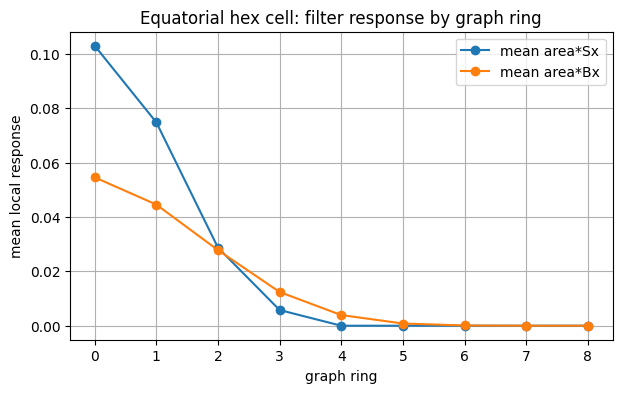

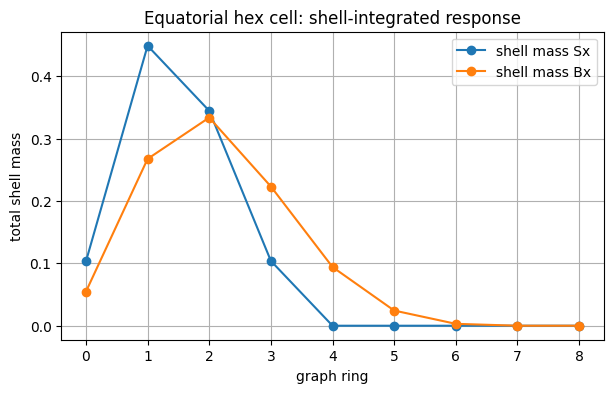

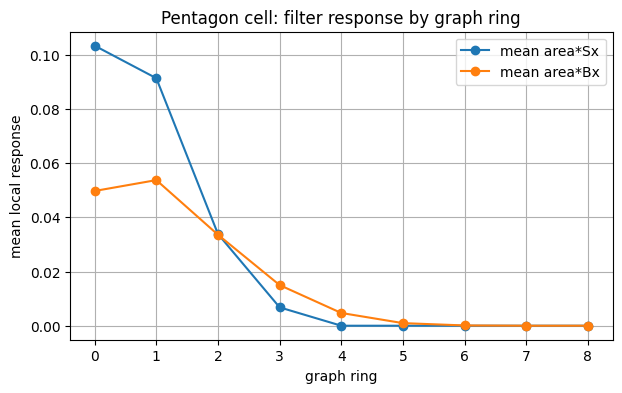

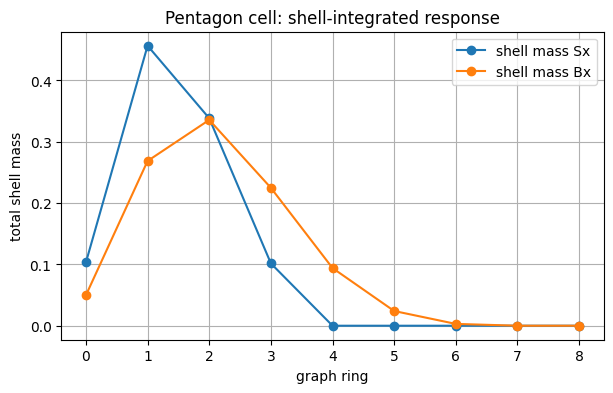

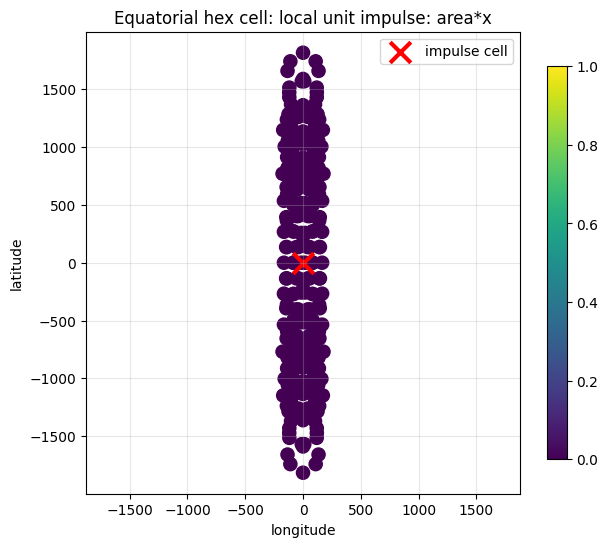

...

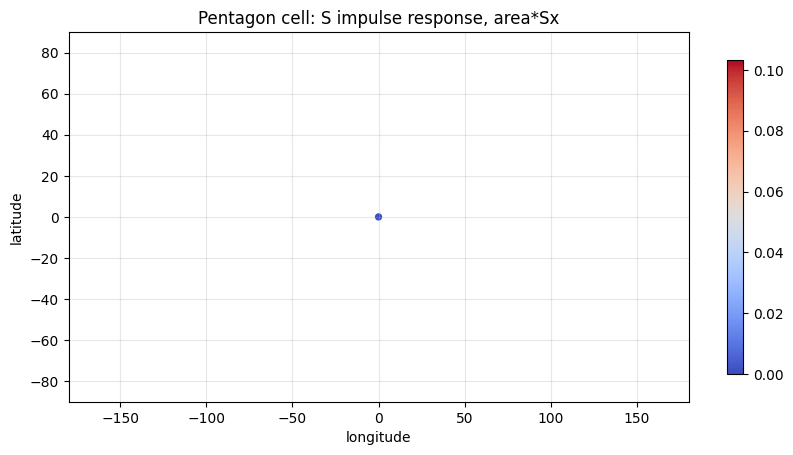

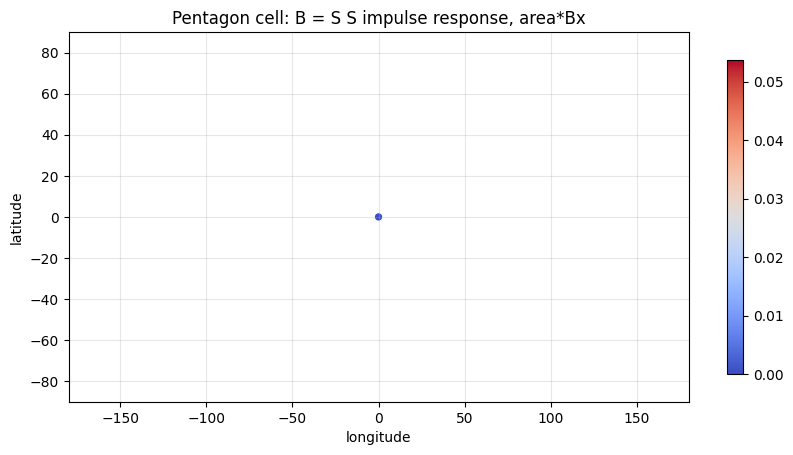

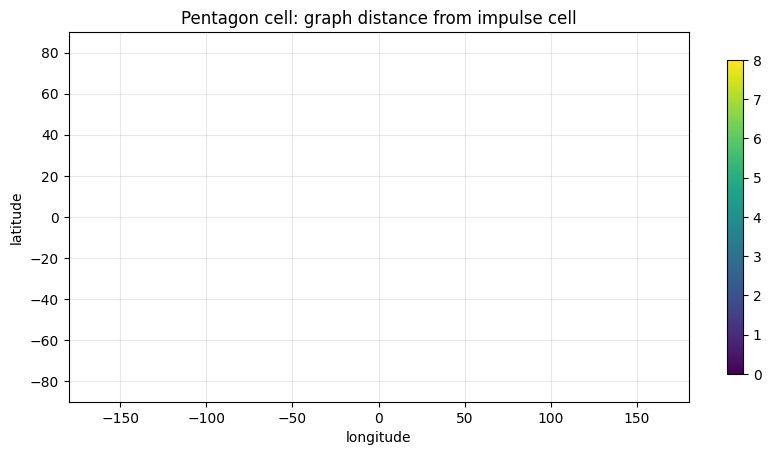

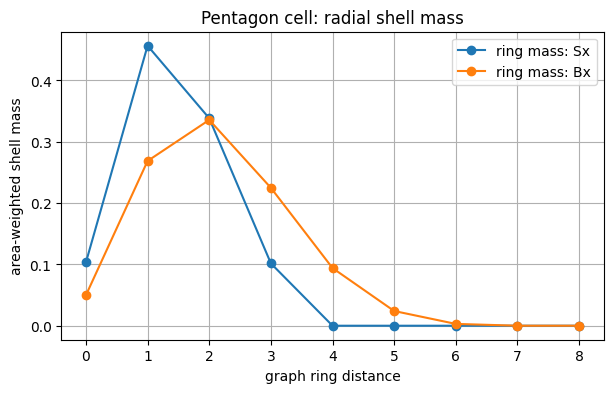

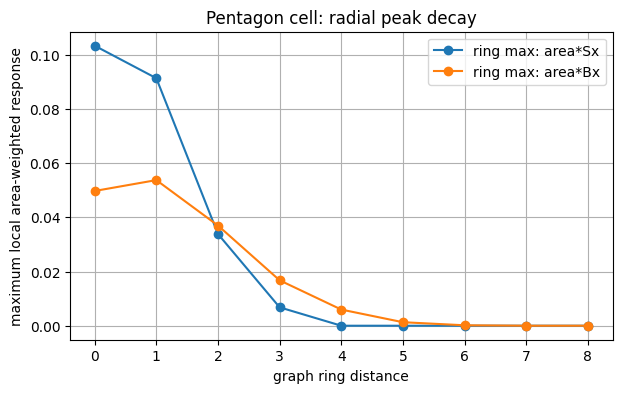

In [ ]:
import numpy as np
import scipy.sparse as sp
import matplotlib.pyplot as plt

# ============================================================
# Configuration
# ============================================================

GRID_FILE = "/content/drive/MyDrive/GLOBAL_SW_FV/grid/global_hex_ico_grid_v0.npz"

R_SUPPORT = 3
SIGMA_R = 1.25
SINKHORN_ITERS = 500
SINKHORN_TOL = 1e-13

# choose impulse locations
USE_EQUATOR_CELL = True
USE_PENTAGON_CELL = True

# plotting
POINT_SIZE = 18
CMAP = "coolwarm"

# ============================================================
# Load grid
# ============================================================

grid = np.load(GRID_FILE, allow_pickle=True)

area = grid["cell_area"].astype(np.float64)
lon = np.rad2deg(grid["cell_center_lon"].astype(np.float64))
lat = np.rad2deg(grid["cell_center_lat"].astype(np.float64))
xyz = grid["cell_center_xyz"].astype(np.float64)

ncells = area.size

print("Number of cells:", ncells)
print("Total area:", area.sum())

# ============================================================
# Build neighbors from primal triangular faces
# ============================================================

def build_neighbors_from_primal_faces(grid, ncells):
    faces = grid["primal_faces"]
    neigh = [set() for _ in range(ncells)]

    for tri in faces:
        tri = np.asarray(tri, dtype=np.int64)
        tri = tri[tri >= 0]

        if len(tri) != 3:
            continue

        a, b, c = tri

        neigh[a].add(b)
        neigh[a].add(c)

        neigh[b].add(a)
        neigh[b].add(c)

        neigh[c].add(a)
        neigh[c].add(b)

    return [sorted(s) for s in neigh]

neighbors = build_neighbors_from_primal_faces(grid, ncells)

deg = np.array([len(n) for n in neighbors])
print("Degree counts:", {int(d): int(np.sum(deg == d)) for d in sorted(set(deg))})

# ============================================================
# Graph-ring tools
# ============================================================

def graph_rings_for_cell(i, neighbors, R):
    visited = {i}
    rings = [[i]]
    frontier = [i]

    for r in range(1, R + 1):
        new_frontier = []
        for q in frontier:
            for j in neighbors[q]:
                if j not in visited:
                    visited.add(j)
                    new_frontier.append(j)

        rings.append(new_frontier)
        frontier = new_frontier

    return rings


def graph_distance_from_cell(i0, neighbors, max_r=None):
    dist = -np.ones(len(neighbors), dtype=np.int64)
    dist[i0] = 0

    frontier = [i0]
    r = 0

    while frontier:
        if max_r is not None and r >= max_r:
            break

        new_frontier = []
        for q in frontier:
            for j in neighbors[q]:
                if dist[j] < 0:
                    dist[j] = dist[q] + 1
                    new_frontier.append(j)

        frontier = new_frontier
        r += 1

    return dist

# ============================================================
# Build symmetric area-normalized smoother S = A^{-1} K
# ============================================================

rows = []
cols = []
vals = []

for i in range(ncells):
    rings = graph_rings_for_cell(i, neighbors, R_SUPPORT)

    for r, ring in enumerate(rings):
        wr = np.exp(-0.5 * (r / SIGMA_R)**2)

        for j in ring:
            rows.append(i)
            cols.append(j)
            vals.append(wr)

K0 = sp.coo_matrix((vals, (rows, cols)), shape=(ncells, ncells)).tocsr()
K0 = 0.5 * (K0 + K0.T)

print("K0 nnz:", K0.nnz)

d = np.ones(ncells, dtype=np.float64)

for it in range(SINKHORN_ITERS):
    Kd = K0 @ d
    row_sum = d * Kd
    ratio = area / np.maximum(row_sum, 1e-300)
    err = np.max(np.abs(ratio - 1.0))

    d *= np.sqrt(ratio)

    if it % 50 == 0:
        print(f"Sinkhorn iter {it:4d}: max ratio error = {err:.3e}")

    if err < SINKHORN_TOL:
        print(f"Sinkhorn converged at iter {it}: error = {err:.3e}")
        break

K = sp.diags(d) @ K0 @ sp.diags(d)
K = K.tocsr()

row_sum = np.asarray(K @ np.ones(ncells)).ravel()
print("K row-sum/area max relative error:",
      np.max(np.abs(row_sum - area)) / np.mean(area))

def S_apply(x):
    return (K @ x) / area

def B_apply(x):
    return S_apply(S_apply(x))

def inner_A(x, y):
    return np.sum(area * x * y)

def mean_A(x):
    return np.sum(area * x) / np.sum(area)

# ============================================================
# Select impulse cells
# ============================================================

# equatorial cell nearest lon=0, lat=0
dist_equator = (lon - 0.0)**2 + (lat - 0.0)**2
i_equator = int(np.argmin(dist_equator))

# one pentagon cell
pentagons = np.where(deg == 5)[0]
i_pentagon = int(pentagons[0])

print("\nImpulse cells:")
print("  equator cell:", i_equator, "lon/lat =", lon[i_equator], lat[i_equator],
      "degree =", deg[i_equator])
print("  pentagon cell:", i_pentagon, "lon/lat =", lon[i_pentagon], lat[i_pentagon],
      "degree =", deg[i_pentagon])

# ============================================================
# Impulse response diagnostics
#
# We define the impulse as x[i0] = 1/area[i0].
# Then integral_A x = 1.
# This is the discrete analog of a unit-mass delta function.
# ============================================================

def impulse_response(i0, label):
    x = np.zeros(ncells, dtype=np.float64)
    x[i0] = 1.0 / area[i0]

    Sx = S_apply(x)
    Bx = B_apply(x)

    print("\n============================================================")
    print(f"IMPULSE RESPONSE: {label}")
    print("============================================================")

    print("Cell:", i0)
    print("lon/lat:", lon[i0], lat[i0])
    print("degree:", deg[i0])
    print("area:", area[i0])

    print("\nMass diagnostics:")
    print("  integral_A x  =", np.sum(area * x))
    print("  integral_A Sx =", np.sum(area * Sx))
    print("  integral_A Bx =", np.sum(area * Bx))

    print("\nPeak diagnostics:")
    print("  max x  =", x.max())
    print("  max Sx =", Sx.max())
    print("  max Bx =", Bx.max())

    print("\nNorm diagnostics:")
    print("  ||x||_A^2  =", inner_A(x, x))
    print("  ||Sx||_A^2 =", inner_A(Sx, Sx))
    print("  ||Bx||_A^2 =", inner_A(Bx, Bx))

    # graph-distance shell diagnostics
    dist = graph_distance_from_cell(i0, neighbors, max_r=2 * R_SUPPORT + 2)

    print("\nRadial shell diagnostics:")
    print("ring   ncell      mass(Sx)        mass(Bx)        mean(Sx)        mean(Bx)")
    for r in range(0, 2 * R_SUPPORT + 3):
        mask = dist == r
        if not np.any(mask):
            continue

        mass_S = np.sum(area[mask] * Sx[mask])
        mass_B = np.sum(area[mask] * Bx[mask])
        mean_S = np.sum(area[mask] * Sx[mask]) / np.sum(area[mask])
        mean_B = np.sum(area[mask] * Bx[mask]) / np.sum(area[mask])

        print(f"{r:4d} {np.sum(mask):7d} {mass_S:14.6e} {mass_B:14.6e} "
              f"{mean_S:14.6e} {mean_B:14.6e}")

    return x, Sx, Bx, dist

x_eq, Sx_eq, Bx_eq, dist_eq = impulse_response(i_equator, "equatorial hex cell")
x_p5, Sx_p5, Bx_p5, dist_p5 = impulse_response(i_pentagon, "pentagon cell")

# ============================================================
# Zoomed local impulse response plots
# ============================================================

def lonlat_distance_deg(lon1, lat1, lon2, lat2):
    """
    Approximate local distance in degrees, good enough only for plot windowing.
    """
    dlon = lon1 - lon2
    dlon = (dlon + 180.0) % 360.0 - 180.0
    dlat = lat1 - lat2
    return np.sqrt((dlon * np.cos(np.deg2rad(lat2)))**2 + dlat**2)


def plot_local_impulse_response(i0, x, Sx, Bx, dist, label, max_ring=8):
    mask = (dist >= 0) & (dist <= max_ring)

    lon0 = lon[i0]
    lat0 = lat[i0]

    local_lon = lon[mask].copy()
    local_lat = lat[mask].copy()

    # shift longitude so impulse is centered, avoiding dateline issues
    local_lon_shift = local_lon.copy()
    local_lon_shift = lon0 + ((local_lon_shift - lon0 + 180.0) % 360.0 - 180.0)

    fields = [
        ("unit impulse: area*x", area[mask] * x[mask]),
        ("S impulse response: area*Sx", area[mask] * Sx[mask]),
        ("B = S S impulse response: area*Bx", area[mask] * Bx[mask]),
        ("graph distance", dist[mask].astype(float)),
    ]

    for title, field in fields:
        plt.figure(figsize=(7, 6))

        sc = plt.scatter(
            local_lon_shift,
            local_lat,
            c=field,
            s=90,
            cmap="viridis"
        )

        plt.scatter(
            [lon0], [lat0],
            s=220,
            marker="x",
            linewidths=3,
            c="red",
            label="impulse cell"
        )

        plt.colorbar(sc, shrink=0.85)
        plt.xlabel("longitude")
        plt.ylabel("latitude")
        plt.title(f"{label}: local {title}")
        plt.grid(True, alpha=0.3)
        plt.legend()
        plt.axis("equal")
        plt.show()

# ============================================================
# Direct filter-response profile by graph ring
# ============================================================

def plot_ring_response_profile(i0, x, Sx, Bx, dist, label, max_ring=8):
    rings = []
    mean_S = []
    mean_B = []
    mass_S = []
    mass_B = []

    for r in range(max_ring + 1):
        mask = dist == r
        if not np.any(mask):
            continue

        rings.append(r)

        mean_S.append(np.mean(area[mask] * Sx[mask]))
        mean_B.append(np.mean(area[mask] * Bx[mask]))

        mass_S.append(np.sum(area[mask] * Sx[mask]))
        mass_B.append(np.sum(area[mask] * Bx[mask]))

    plt.figure(figsize=(7, 4))
    plt.plot(rings, mean_S, "o-", label="mean area*Sx")
    plt.plot(rings, mean_B, "o-", label="mean area*Bx")
    plt.xlabel("graph ring")
    plt.ylabel("mean local response")
    plt.title(f"{label}: filter response by graph ring")
    plt.grid(True)
    plt.legend()
    plt.show()

    plt.figure(figsize=(7, 4))
    plt.plot(rings, mass_S, "o-", label="shell mass Sx")
    plt.plot(rings, mass_B, "o-", label="shell mass Bx")
    plt.xlabel("graph ring")
    plt.ylabel("total shell mass")
    plt.title(f"{label}: shell-integrated response")
    plt.grid(True)
    plt.legend()
    plt.show()


plot_ring_response_profile(
    i_equator, x_eq, Sx_eq, Bx_eq, dist_eq,
    "Equatorial hex cell",
    max_ring=8
)

plot_ring_response_profile(
    i_pentagon, x_p5, Sx_p5, Bx_p5, dist_p5,
    "Pentagon cell",
    max_ring=8
)

plot_local_impulse_response(
    i_equator, x_eq, Sx_eq, Bx_eq, dist_eq,
    "Equatorial hex cell",
    max_ring=8
)

plot_local_impulse_response(
    i_pentagon, x_p5, Sx_p5, Bx_p5, dist_p5,
    "Pentagon cell",
    max_ring=8
)

# ============================================================
# Plot helpers
# ============================================================

def scatter_map(field, title, point_size=POINT_SIZE, cmap=CMAP, symmetric=False):
    plt.figure(figsize=(10, 4.8))

    if symmetric:
        vmax = np.nanmax(np.abs(field))
        vmin = -vmax
    else:
        vmin = np.nanmin(field)
        vmax = np.nanmax(field)

    sc = plt.scatter(lon, lat, c=field, s=point_size, cmap=cmap, vmin=vmin, vmax=vmax)
    plt.colorbar(sc, shrink=0.85)
    plt.xlabel("longitude")
    plt.ylabel("latitude")
    plt.title(title)
    plt.grid(True, alpha=0.3)
    plt.xlim(-180, 180)
    plt.ylim(-90, 90)
    plt.show()


def plot_impulse_maps(x, Sx, Bx, dist, label):
    # For impulse fields, plotting area * value is easier to interpret as local mass density.
    scatter_map(area * x,  f"{label}: unit impulse, area*x")
    scatter_map(area * Sx, f"{label}: S impulse response, area*Sx")
    scatter_map(area * Bx, f"{label}: B = S S impulse response, area*Bx")

    # Also plot graph distance support
    dist_plot = dist.astype(float)
    dist_plot[dist_plot < 0] = np.nan
    scatter_map(dist_plot, f"{label}: graph distance from impulse cell",
                cmap="viridis")

def plot_radial_profile(dist, Sx, Bx, label):
    rings = []
    mass_S = []
    mass_B = []
    max_S = []
    max_B = []

    for r in range(0, 2 * R_SUPPORT + 3):
        mask = dist == r
        if not np.any(mask):
            continue

        rings.append(r)
        mass_S.append(np.sum(area[mask] * Sx[mask]))
        mass_B.append(np.sum(area[mask] * Bx[mask]))
        max_S.append(np.max(area[mask] * Sx[mask]))
        max_B.append(np.max(area[mask] * Bx[mask]))

    plt.figure(figsize=(7, 4))
    plt.plot(rings, mass_S, "o-", label="ring mass: Sx")
    plt.plot(rings, mass_B, "o-", label="ring mass: Bx")
    plt.xlabel("graph ring distance")
    plt.ylabel("area-weighted shell mass")
    plt.title(f"{label}: radial shell mass")
    plt.grid(True)
    plt.legend()
    plt.show()

    plt.figure(figsize=(7, 4))
    plt.plot(rings, max_S, "o-", label="ring max: area*Sx")
    plt.plot(rings, max_B, "o-", label="ring max: area*Bx")
    plt.xlabel("graph ring distance")
    plt.ylabel("maximum local area-weighted response")
    plt.title(f"{label}: radial peak decay")
    plt.grid(True)
    plt.legend()
    plt.show()



# ============================================================
# Produce plots
# ============================================================

plot_impulse_maps(x_eq, Sx_eq, Bx_eq, dist_eq, "Equatorial hex cell")
plot_radial_profile(dist_eq, Sx_eq, Bx_eq, "Equatorial hex cell")

plot_impulse_maps(x_p5, Sx_p5, Bx_p5, dist_p5, "Pentagon cell")
plot_radial_profile(dist_p5, Sx_p5, Bx_p5, "Pentagon cell")

# test_clean_impluts_resoponse_level0_v1.py

Number of cells: 2562
Area min/max: 134536555820.17395 238195365847.2499
Total area: 510099699070761.6
Degree counts: {5: 12, 6: 2550}
K0 nnz: 94422
Sinkhorn iter    0: max ratio error = 2.455e+10
Sinkhorn converged at iter 41: error = 9.970e-14
K row-sum/area max relative error: 3.433382122534929e-14

Self-adjointness test for B = S S
  <x, B y>_A = -3041882380559.1626
  <B x, y>_A = -3041882380559.163
  relative error = 1.6051943793771653e-16

Impulse cells:
  equator cell: 38 lon/lat = 0.0 0.0 degree = 6
  pentagon cell: 0 lon/lat = 6973.897576768309 0.0 degree = 5

CLEAN FILTER RESPONSE: Equatorial hex cell
Impulse cell: 38
lon/lat: 0.0 0.0
degree: 6
area: 199901681988.97357

Mass checks:
  integral_A(delta)         = 1.0
  integral_A(after adjoint) = 0.9999999999999987
  integral_A(response)      = 0.9999999999999989

Peak checks:
  max area*delta          = 1.0
  max area*after_adjoint  = 0.10298043051624478
  max area*response       = 0.05456863631627564

Norm checks:
  ||delta|

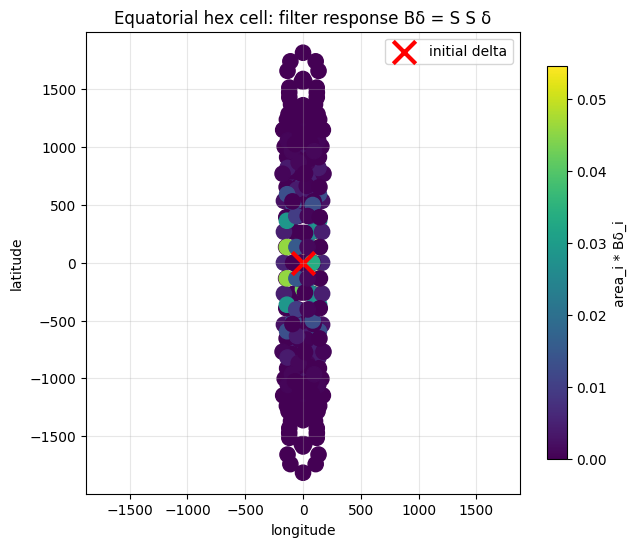

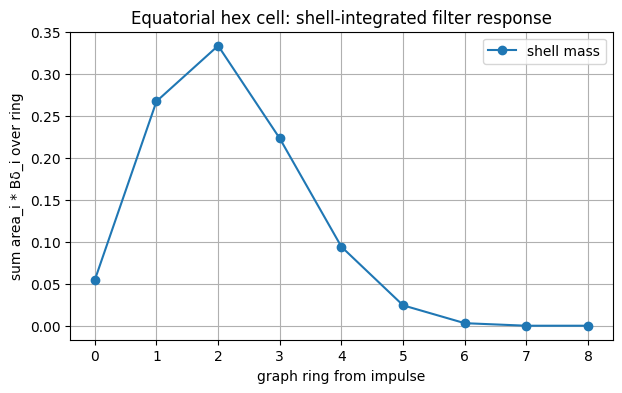

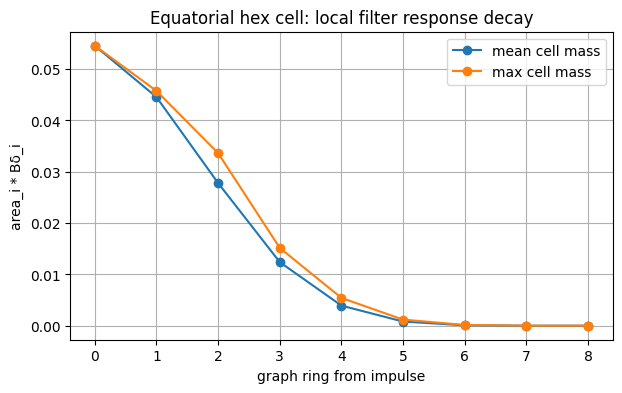

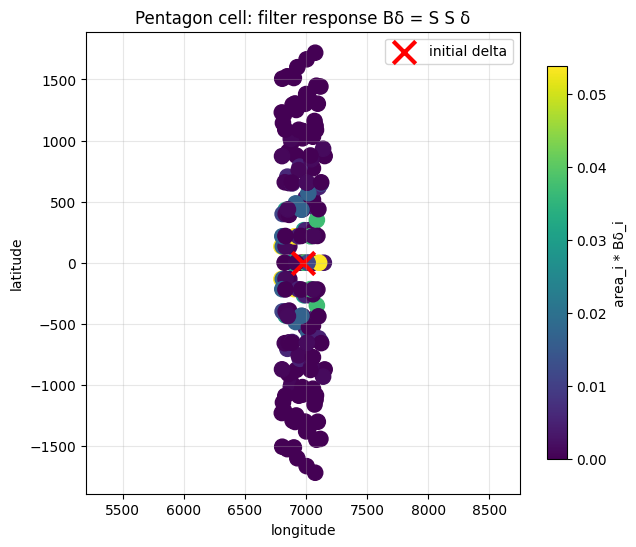

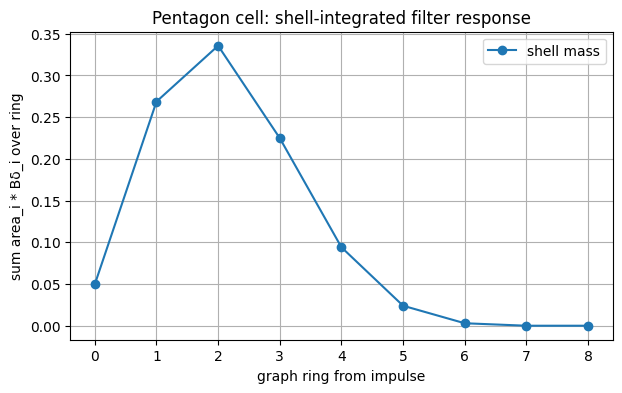

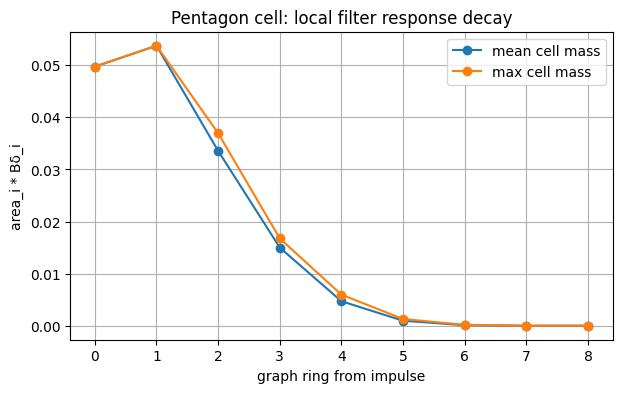

In [ ]:
import numpy as np
import scipy.sparse as sp
import matplotlib.pyplot as plt

# ============================================================
# Configuration
# ============================================================

GRID_FILE = "/content/drive/MyDrive/GLOBAL_SW_FV/grid/global_hex_ico_grid_v0.npz"

R_SUPPORT = 3
SIGMA_R = 1.25
SINKHORN_ITERS = 500
SINKHORN_TOL = 1e-13

MAX_PLOT_RING = 8
POINT_SIZE = 120

# ============================================================
# Load grid
# ============================================================

grid = np.load(GRID_FILE, allow_pickle=True)

area = grid["cell_area"].astype(np.float64)
lon = np.rad2deg(grid["cell_center_lon"].astype(np.float64))
lat = np.rad2deg(grid["cell_center_lat"].astype(np.float64))

ncells = area.size

print("Number of cells:", ncells)
print("Area min/max:", area.min(), area.max())
print("Total area:", area.sum())

# ============================================================
# Build neighbors from primal triangular faces
# ============================================================

def build_neighbors_from_primal_faces(grid, ncells):
    faces = grid["primal_faces"]
    neigh = [set() for _ in range(ncells)]

    for tri in faces:
        tri = np.asarray(tri, dtype=np.int64)
        tri = tri[tri >= 0]

        if len(tri) != 3:
            continue

        a, b, c = tri

        neigh[a].add(b)
        neigh[a].add(c)
        neigh[b].add(a)
        neigh[b].add(c)
        neigh[c].add(a)
        neigh[c].add(b)

    return [sorted(s) for s in neigh]

neighbors = build_neighbors_from_primal_faces(grid, ncells)

deg = np.array([len(n) for n in neighbors])
print("Degree counts:", {int(d): int(np.sum(deg == d)) for d in sorted(set(deg))})

# ============================================================
# Graph rings / graph distance
# ============================================================

def graph_rings_for_cell(i, neighbors, R):
    visited = {i}
    rings = [[i]]
    frontier = [i]

    for r in range(1, R + 1):
        new_frontier = []

        for q in frontier:
            for j in neighbors[q]:
                if j not in visited:
                    visited.add(j)
                    new_frontier.append(j)

        rings.append(new_frontier)
        frontier = new_frontier

    return rings


def graph_distance_from_cell(i0, neighbors, max_r=None):
    dist = -np.ones(len(neighbors), dtype=np.int64)
    dist[i0] = 0

    frontier = [i0]

    while frontier:
        new_frontier = []

        for q in frontier:
            if max_r is not None and dist[q] >= max_r:
                continue

            for j in neighbors[q]:
                if dist[j] < 0:
                    dist[j] = dist[q] + 1
                    new_frontier.append(j)

        frontier = new_frontier

    return dist

# ============================================================
# Build symmetric graph kernel K0
# ============================================================

rows = []
cols = []
vals = []

for i in range(ncells):
    rings = graph_rings_for_cell(i, neighbors, R_SUPPORT)

    for r, ring in enumerate(rings):
        wr = np.exp(-0.5 * (r / SIGMA_R) ** 2)

        for j in ring:
            rows.append(i)
            cols.append(j)
            vals.append(wr)

K0 = sp.coo_matrix((vals, (rows, cols)), shape=(ncells, ncells)).tocsr()
K0 = 0.5 * (K0 + K0.T)

print("K0 nnz:", K0.nnz)

# ============================================================
# Symmetric Sinkhorn normalization
#
# Construct K = D K0 D such that:
#
#     K 1 = area
#
# Then:
#
#     S = A^{-1} K
#
# is area-mean conserving and self-adjoint under:
#
#     <x,y>_A = sum_i area_i x_i y_i
# ============================================================

d = np.ones(ncells, dtype=np.float64)

for it in range(SINKHORN_ITERS):
    Kd = K0 @ d
    row_sum = d * Kd

    ratio = area / np.maximum(row_sum, 1e-300)
    err = np.max(np.abs(ratio - 1.0))

    d *= np.sqrt(ratio)

    if it % 50 == 0:
        print(f"Sinkhorn iter {it:4d}: max ratio error = {err:.3e}")

    if err < SINKHORN_TOL:
        print(f"Sinkhorn converged at iter {it}: error = {err:.3e}")
        break

K = sp.diags(d) @ K0 @ sp.diags(d)
K = K.tocsr()

row_sum = np.asarray(K @ np.ones(ncells)).ravel()
print("K row-sum/area max relative error:",
      np.max(np.abs(row_sum - area)) / np.mean(area))

# ============================================================
# Operators
# ============================================================

def S_apply(x):
    return (K @ x) / area


def inner_A(x, y):
    return np.sum(area * x * y)


def integral_A(x):
    return np.sum(area * x)


def B_apply(x):
    # one-generation self-adjoint filter:
    # adjoint filter followed by direct filter
    return S_apply(S_apply(x))

# ============================================================
# Basic self-adjoint filter test
# ============================================================

rng = np.random.default_rng(1234)
x = rng.standard_normal(ncells)
y = rng.standard_normal(ncells)

lhs = inner_A(x, B_apply(y))
rhs = inner_A(B_apply(x), y)

print("\nSelf-adjointness test for B = S S")
print("  <x, B y>_A =", lhs)
print("  <B x, y>_A =", rhs)
print("  relative error =", abs(lhs - rhs) / max(abs(lhs), abs(rhs), 1e-300))

# ============================================================
# Select impulse cells
# ============================================================

i_equator = int(np.argmin((lon - 0.0) ** 2 + (lat - 0.0) ** 2))

pentagons = np.where(deg == 5)[0]
i_pentagon = int(pentagons[0])

print("\nImpulse cells:")
print("  equator cell:", i_equator, "lon/lat =", lon[i_equator], lat[i_equator],
      "degree =", deg[i_equator])
print("  pentagon cell:", i_pentagon, "lon/lat =", lon[i_pentagon], lat[i_pentagon],
      "degree =", deg[i_pentagon])

# ============================================================
# Clean delta impulse response
# ============================================================

def clean_impulse_response(i0, label, max_ring=MAX_PLOT_RING):
    print("\n============================================================")
    print(f"CLEAN FILTER RESPONSE: {label}")
    print("============================================================")

    # Unit-mass delta:
    #
    #     integral_A(delta) = 1
    #
    delta = np.zeros(ncells, dtype=np.float64)
    delta[i0] = 1.0 / area[i0]

    # Full self-adjoint filter:
    #
    #     response = direct_filter(adjoint_filter(delta))
    #              = S S delta
    #
    after_adjoint = S_apply(delta)
    response = S_apply(after_adjoint)

    dist = graph_distance_from_cell(i0, neighbors, max_r=max_ring)

    print("Impulse cell:", i0)
    print("lon/lat:", lon[i0], lat[i0])
    print("degree:", deg[i0])
    print("area:", area[i0])

    print("\nMass checks:")
    print("  integral_A(delta)         =", integral_A(delta))
    print("  integral_A(after adjoint) =", integral_A(after_adjoint))
    print("  integral_A(response)      =", integral_A(response))

    print("\nPeak checks:")
    print("  max area*delta          =", np.max(area * delta))
    print("  max area*after_adjoint  =", np.max(area * after_adjoint))
    print("  max area*response       =", np.max(area * response))

    print("\nNorm checks:")
    print("  ||delta||_A^2         =", inner_A(delta, delta))
    print("  ||after_adjoint||_A^2 =", inner_A(after_adjoint, after_adjoint))
    print("  ||response||_A^2      =", inner_A(response, response))

    print("\nRing shell mass of final response:")
    for r in range(max_ring + 1):
        m = dist == r
        if not np.any(m):
            continue
        shell_mass = np.sum(area[m] * response[m])
        print(f"  ring {r:2d}: {shell_mass:.10e}")

    return delta, after_adjoint, response, dist


delta_eq, adj_eq, resp_eq, dist_eq = clean_impulse_response(
    i_equator,
    "Equatorial hex cell",
    max_ring=MAX_PLOT_RING
)

delta_p5, adj_p5, resp_p5, dist_p5 = clean_impulse_response(
    i_pentagon,
    "Pentagon cell",
    max_ring=MAX_PLOT_RING
)

# ============================================================
# Plotting
# ============================================================

def shifted_local_lon(lon_values, lon0):
    return lon0 + ((lon_values - lon0 + 180.0) % 360.0 - 180.0)


def plot_filter_response_map(i0, response, dist, label, max_ring=MAX_PLOT_RING):
    mask = (dist >= 0) & (dist <= max_ring)

    lon0 = lon[i0]
    lat0 = lat[i0]

    local_lon = shifted_local_lon(lon[mask], lon0)
    local_lat = lat[mask]

    # This is the clearest quantity:
    #
    #     area_i * response_i
    #
    # It represents the fraction of unit impulse mass assigned to each cell.
    response_mass = area[mask] * response[mask]

    plt.figure(figsize=(7, 6))
    sc = plt.scatter(
        local_lon,
        local_lat,
        c=response_mass,
        s=POINT_SIZE,
        cmap="viridis"
    )

    plt.scatter(
        [lon0],
        [lat0],
        marker="x",
        s=260,
        c="red",
        linewidths=3,
        label="initial delta"
    )

    plt.colorbar(sc, shrink=0.85, label="area_i * Bδ_i")
    plt.xlabel("longitude")
    plt.ylabel("latitude")
    plt.title(f"{label}: filter response Bδ = S S δ")
    plt.grid(True, alpha=0.3)
    plt.axis("equal")
    plt.legend()
    plt.show()


def plot_radial_response(response, dist, label, max_ring=MAX_PLOT_RING):
    rings = []
    shell_mass = []
    mean_cell_mass = []
    max_cell_mass = []

    for r in range(max_ring + 1):
        m = dist == r
        if not np.any(m):
            continue

        cell_mass = area[m] * response[m]

        rings.append(r)
        shell_mass.append(np.sum(cell_mass))
        mean_cell_mass.append(np.mean(cell_mass))
        max_cell_mass.append(np.max(cell_mass))

    plt.figure(figsize=(7, 4))
    plt.plot(rings, shell_mass, "o-", label="shell mass")
    plt.xlabel("graph ring from impulse")
    plt.ylabel("sum area_i * Bδ_i over ring")
    plt.title(f"{label}: shell-integrated filter response")
    plt.grid(True)
    plt.legend()
    plt.show()

    plt.figure(figsize=(7, 4))
    plt.plot(rings, mean_cell_mass, "o-", label="mean cell mass")
    plt.plot(rings, max_cell_mass, "o-", label="max cell mass")
    plt.xlabel("graph ring from impulse")
    plt.ylabel("area_i * Bδ_i")
    plt.title(f"{label}: local filter response decay")
    plt.grid(True)
    plt.legend()
    plt.show()


# ============================================================
# Make the clean response plots
# ============================================================

plot_filter_response_map(
    i_equator,
    resp_eq,
    dist_eq,
    "Equatorial hex cell",
    max_ring=MAX_PLOT_RING
)

plot_radial_response(
    resp_eq,
    dist_eq,
    "Equatorial hex cell",
    max_ring=MAX_PLOT_RING
)

plot_filter_response_map(
    i_pentagon,
    resp_p5,
    dist_p5,
    "Pentagon cell",
    max_ring=MAX_PLOT_RING
)

plot_radial_response(
    resp_p5,
    dist_p5,
    "Pentagon cell",
    max_ring=MAX_PLOT_RING
)

# test_clean_impulse_response_tangent_level0_v2.py

Number of cells: 2562
Area min/max: 134536555820.17395 238195365847.2499
Total area: 510099699070761.6
lon range: -177.15991793333276 180.0
lat range: -90.0 90.0
Degree counts: {5: 12, 6: 2550}
K0 nnz: 94422
Sinkhorn iter    0: max ratio error = 2.455e+10
Sinkhorn converged at iter 41: error = 9.970e-14
K row-sum/area max relative error: 3.433382122534929e-14

Self-adjointness test for B = S S
  relative error = 1.6051943793771653e-16

Impulse cells:
  equator: 38 lon/lat = 0.0 0.0 deg = 6
  pentagon: 0 lon/lat = 121.717474411461 0.0 deg = 5

Equatorial hex cell
cell: 38
lon/lat: 0.0 0.0
degree: 6
area: 199901681988.97357

Mass:
  integral_A(delta)    = 1.0
  integral_A(S delta)  = 0.9999999999999987
  integral_A(B delta)  = 0.9999999999999989

Peak mass per cell:
  max area*delta   = 1.0
  max area*Sdelta  = 0.10298043051624478
  max area*Bdelta  = 0.05456863631627564

Ring shell mass of B delta:
  ring  0: 5.4568636316e-02
  ring  1: 2.6733254612e-01
  ring  2: 3.3359533081e-01
  rin

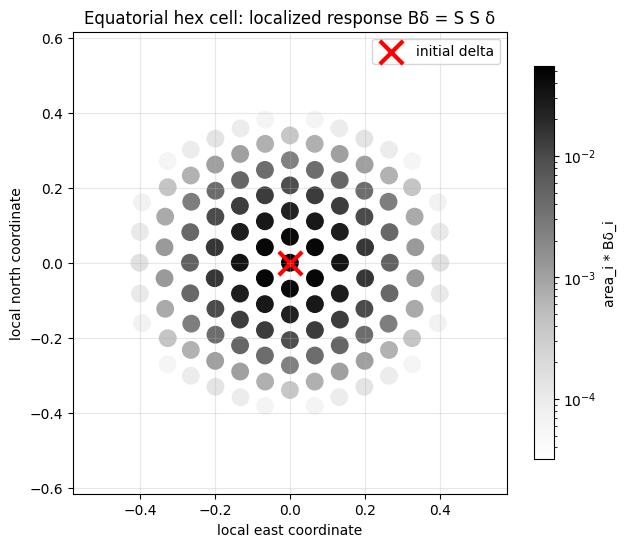


Equatorial hex cell: plotted cells = 217
sum plotted area*Bdelta = 0.9999999999999989


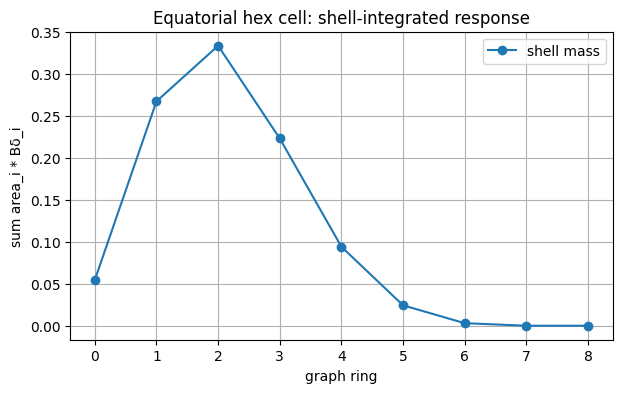

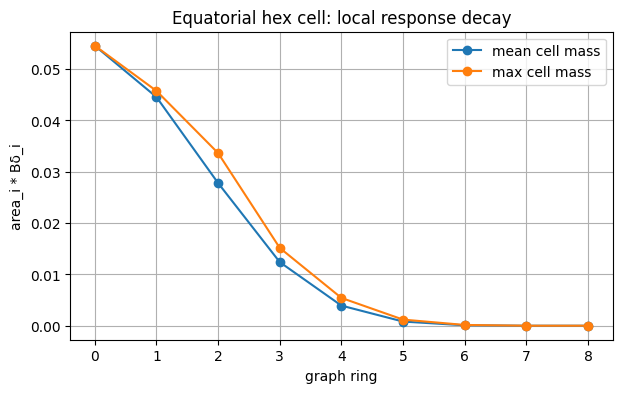

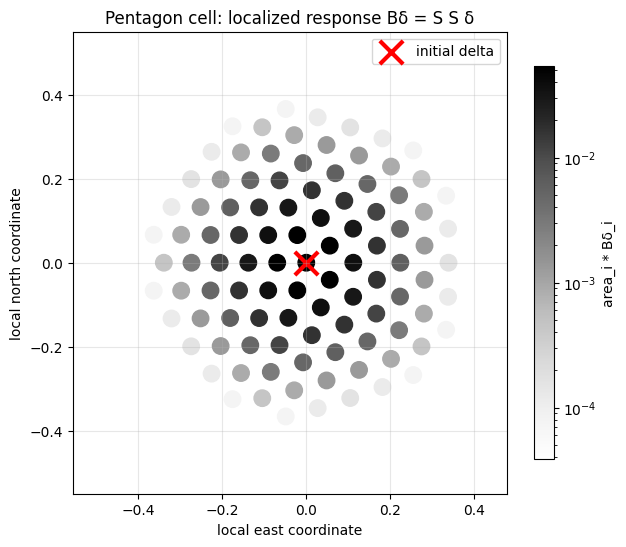


Pentagon cell: plotted cells = 181
sum plotted area*Bdelta = 1.0000000000000493


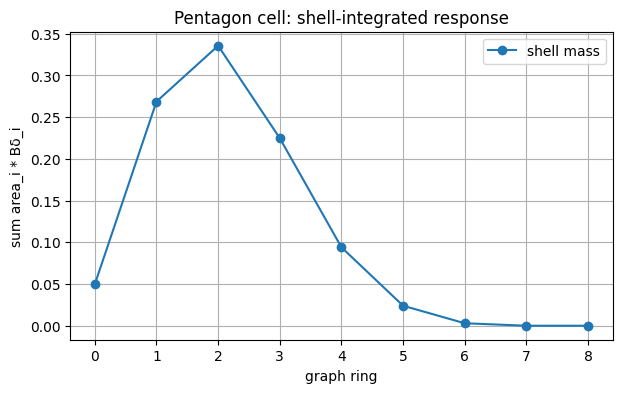

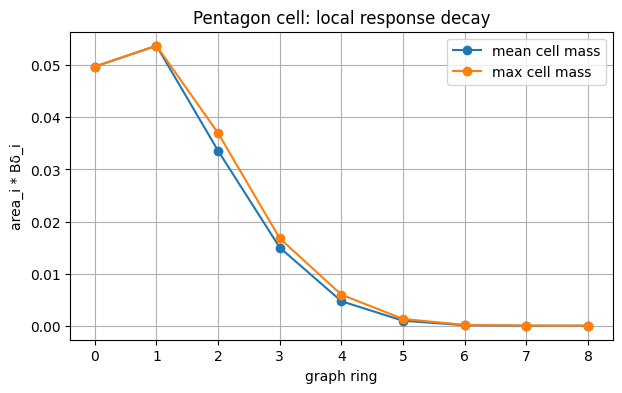

In [ ]:
import numpy as np
import scipy.sparse as sp
import matplotlib.pyplot as plt

from matplotlib.colors import LogNorm

# ============================================================
# Configuration
# ============================================================

GRID_FILE = "/content/drive/MyDrive/GLOBAL_SW_FV/grid/global_hex_ico_grid_v0.npz"

R_SUPPORT = 3
SIGMA_R = 1.25
SINKHORN_ITERS = 500
SINKHORN_TOL = 1e-13

MAX_PLOT_RING = 8
POINT_SIZE = 140

# ============================================================
# Load grid
# ============================================================

grid = np.load(GRID_FILE, allow_pickle=True)

area = grid["cell_area"].astype(np.float64)
xyz = grid["cell_center_xyz"].astype(np.float64)

lon_raw = grid["cell_center_lon"].astype(np.float64)
lat_raw = grid["cell_center_lat"].astype(np.float64)

# auto-detect radians versus degrees
if np.max(np.abs(lon_raw)) <= 2.0 * np.pi + 1e-6:
    lon = np.rad2deg(lon_raw)
    lat = np.rad2deg(lat_raw)
else:
    lon = lon_raw
    lat = lat_raw

ncells = area.size

print("Number of cells:", ncells)
print("Area min/max:", area.min(), area.max())
print("Total area:", area.sum())
print("lon range:", lon.min(), lon.max())
print("lat range:", lat.min(), lat.max())

# ============================================================
# Build neighbors
# ============================================================

def build_neighbors_from_primal_faces(grid, ncells):
    faces = grid["primal_faces"]
    neigh = [set() for _ in range(ncells)]

    for tri in faces:
        tri = np.asarray(tri, dtype=np.int64)
        tri = tri[tri >= 0]

        if len(tri) != 3:
            continue

        a, b, c = tri
        neigh[a].add(b); neigh[a].add(c)
        neigh[b].add(a); neigh[b].add(c)
        neigh[c].add(a); neigh[c].add(b)

    return [sorted(s) for s in neigh]

neighbors = build_neighbors_from_primal_faces(grid, ncells)
deg = np.array([len(n) for n in neighbors])

print("Degree counts:", {int(d): int(np.sum(deg == d)) for d in sorted(set(deg))})

# ============================================================
# Graph rings
# ============================================================

def graph_rings_for_cell(i, neighbors, R):
    visited = {i}
    rings = [[i]]
    frontier = [i]

    for r in range(1, R + 1):
        new_frontier = []

        for q in frontier:
            for j in neighbors[q]:
                if j not in visited:
                    visited.add(j)
                    new_frontier.append(j)

        rings.append(new_frontier)
        frontier = new_frontier

    return rings


def graph_distance_from_cell(i0, neighbors, max_r=None):
    dist = -np.ones(len(neighbors), dtype=np.int64)
    dist[i0] = 0
    frontier = [i0]

    while frontier:
        new_frontier = []

        for q in frontier:
            if max_r is not None and dist[q] >= max_r:
                continue

            for j in neighbors[q]:
                if dist[j] < 0:
                    dist[j] = dist[q] + 1
                    new_frontier.append(j)

        frontier = new_frontier

    return dist

# ============================================================
# Build graph smoother S = A^{-1} K
# ============================================================

rows, cols, vals = [], [], []

for i in range(ncells):
    rings = graph_rings_for_cell(i, neighbors, R_SUPPORT)

    for r, ring in enumerate(rings):
        wr = np.exp(-0.5 * (r / SIGMA_R) ** 2)

        for j in ring:
            rows.append(i)
            cols.append(j)
            vals.append(wr)

K0 = sp.coo_matrix((vals, (rows, cols)), shape=(ncells, ncells)).tocsr()
K0 = 0.5 * (K0 + K0.T)

print("K0 nnz:", K0.nnz)

d = np.ones(ncells, dtype=np.float64)

for it in range(SINKHORN_ITERS):
    Kd = K0 @ d
    row_sum = d * Kd

    ratio = area / np.maximum(row_sum, 1e-300)
    err = np.max(np.abs(ratio - 1.0))

    d *= np.sqrt(ratio)

    if it % 50 == 0:
        print(f"Sinkhorn iter {it:4d}: max ratio error = {err:.3e}")

    if err < SINKHORN_TOL:
        print(f"Sinkhorn converged at iter {it}: error = {err:.3e}")
        break

K = sp.diags(d) @ K0 @ sp.diags(d)
K = K.tocsr()

row_sum = np.asarray(K @ np.ones(ncells)).ravel()
print("K row-sum/area max relative error:",
      np.max(np.abs(row_sum - area)) / np.mean(area))

def S_apply(x):
    return (K @ x) / area

def B_apply(x):
    return S_apply(S_apply(x))

def inner_A(x, y):
    return np.sum(area * x * y)

def integral_A(x):
    return np.sum(area * x)

# ============================================================
# Tests
# ============================================================

rng = np.random.default_rng(1234)
x = rng.standard_normal(ncells)
y = rng.standard_normal(ncells)

lhs = inner_A(x, B_apply(y))
rhs = inner_A(B_apply(x), y)

print("\nSelf-adjointness test for B = S S")
print("  relative error =", abs(lhs - rhs) / max(abs(lhs), abs(rhs), 1e-300))

# ============================================================
# Select impulse cells
# ============================================================

i_equator = int(np.argmin((lon - 0.0) ** 2 + (lat - 0.0) ** 2))
i_pentagon = int(np.where(deg == 5)[0][0])

print("\nImpulse cells:")
print("  equator:", i_equator, "lon/lat =", lon[i_equator], lat[i_equator], "deg =", deg[i_equator])
print("  pentagon:", i_pentagon, "lon/lat =", lon[i_pentagon], lat[i_pentagon], "deg =", deg[i_pentagon])

# ============================================================
# Impulse response
# ============================================================

def compute_impulse_response(i0, max_ring=MAX_PLOT_RING):
    delta = np.zeros(ncells, dtype=np.float64)
    delta[i0] = 1.0 / area[i0]

    after_adjoint = S_apply(delta)
    response = S_apply(after_adjoint)

    dist = graph_distance_from_cell(i0, neighbors, max_r=max_ring)

    return delta, after_adjoint, response, dist

delta_eq, adj_eq, resp_eq, dist_eq = compute_impulse_response(i_equator)
delta_p5, adj_p5, resp_p5, dist_p5 = compute_impulse_response(i_pentagon)

# ============================================================
# Diagnostics
# ============================================================

def print_impulse_diagnostics(i0, delta, adjoint_response, response, dist, label, max_ring=MAX_PLOT_RING):
    print("\n============================================================")
    print(label)
    print("============================================================")
    print("cell:", i0)
    print("lon/lat:", lon[i0], lat[i0])
    print("degree:", deg[i0])
    print("area:", area[i0])

    print("\nMass:")
    print("  integral_A(delta)    =", integral_A(delta))
    print("  integral_A(S delta)  =", integral_A(adjoint_response))
    print("  integral_A(B delta)  =", integral_A(response))

    print("\nPeak mass per cell:")
    print("  max area*delta   =", np.max(area * delta))
    print("  max area*Sdelta  =", np.max(area * adjoint_response))
    print("  max area*Bdelta  =", np.max(area * response))

    print("\nRing shell mass of B delta:")
    for r in range(max_ring + 1):
        m = dist == r
        if np.any(m):
            print(f"  ring {r:2d}: {np.sum(area[m] * response[m]):.10e}")

print_impulse_diagnostics(i_equator, delta_eq, adj_eq, resp_eq, dist_eq, "Equatorial hex cell")
print_impulse_diagnostics(i_pentagon, delta_p5, adj_p5, resp_p5, dist_p5, "Pentagon cell")

# ============================================================
# Local tangent-plane plot
# ============================================================

def tangent_coordinates(i0, mask):
    x0 = xyz[i0].astype(np.float64)
    x0 = x0 / np.linalg.norm(x0)

    zaxis = np.array([0.0, 0.0, 1.0])
    east = np.cross(zaxis, x0)

    if np.linalg.norm(east) < 1e-12:
        east = np.array([1.0, 0.0, 0.0])
    else:
        east = east / np.linalg.norm(east)

    north = np.cross(x0, east)
    north = north / np.linalg.norm(north)

    X = xyz[mask].astype(np.float64)
    X = X / np.linalg.norm(X, axis=1)[:, None]

    dx = X - x0[None, :]

    xe = dx @ east
    yn = dx @ north

    return xe, yn


def plot_tangent_response(i0, response, dist, label, max_ring=MAX_PLOT_RING):
    mask = (dist >= 0) & (dist <= max_ring)

    xe, yn = tangent_coordinates(i0, mask)
    response_mass = area[mask] * response[mask]

    plt.figure(figsize=(7, 6))
    from matplotlib.colors import PowerNorm

    sc = plt.scatter(
        xe,
        yn,
        c=response_mass,
        s=POINT_SIZE,
        cmap="Greys",
        #norm=PowerNorm(gamma=0.5)
        norm=LogNorm()
    )


    plt.scatter(
        [0.0],
        [0.0],
        marker="x",
        s=280,
        c="red",
        linewidths=3,
        label="initial delta"
    )

    plt.colorbar(sc, shrink=0.85, label="area_i * Bδ_i")
    plt.xlabel("local east coordinate")
    plt.ylabel("local north coordinate")
    plt.title(f"{label}: localized response Bδ = S S δ")
    plt.axis("equal")
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.show()

    print(f"\n{label}: plotted cells =", np.sum(mask))
    print("sum plotted area*Bdelta =", np.sum(response_mass))


def plot_radial_response(response, dist, label, max_ring=MAX_PLOT_RING):
    rings = []
    shell_mass = []
    mean_cell_mass = []
    max_cell_mass = []

    for r in range(max_ring + 1):
        m = dist == r
        if not np.any(m):
            continue

        cell_mass = area[m] * response[m]

        rings.append(r)
        shell_mass.append(np.sum(cell_mass))
        mean_cell_mass.append(np.mean(cell_mass))
        max_cell_mass.append(np.max(cell_mass))

    plt.figure(figsize=(7, 4))
    plt.plot(rings, shell_mass, "o-", label="shell mass")
    plt.xlabel("graph ring")
    plt.ylabel("sum area_i * Bδ_i")
    plt.title(f"{label}: shell-integrated response")
    plt.grid(True)
    plt.legend()
    plt.show()

    plt.figure(figsize=(7, 4))
    plt.plot(rings, mean_cell_mass, "o-", label="mean cell mass")
    plt.plot(rings, max_cell_mass, "o-", label="max cell mass")
    plt.xlabel("graph ring")
    plt.ylabel("area_i * Bδ_i")
    plt.title(f"{label}: local response decay")
    plt.grid(True)
    plt.legend()
    plt.show()

# ============================================================
# Plots
# ============================================================

plot_tangent_response(i_equator, resp_eq, dist_eq, "Equatorial hex cell")
plot_radial_response(resp_eq, dist_eq, "Equatorial hex cell")

plot_tangent_response(i_pentagon, resp_p5, dist_p5, "Pentagon cell")
plot_radial_response(resp_p5, dist_p5, "Pentagon cell")

# test_pentagon_defect_impulse_response_v0.py

1. hexagon far from pentagon
2. hexagon adjacent to pentagon
3. pentagon impulse

Number of cells: 2562
Area min/max: 134536555820.17395 238195365847.2499
Total area: 510099699070761.6
lon range: -177.15991793333276 180.0
lat range: -90.0 90.0
Degree counts: {5: 12, 6: 2550}
Sinkhorn iter    0: max ratio error = 2.455e+10
Sinkhorn converged at iter 41: error = 9.970e-14
K row-sum/area max relative error: 3.433382122534929e-14

Selected impulse cases:
Hex far from pentagon       : cell=  189, degree=6, dist_to_pent=10, lon=-128.449, lat= -34.351
Hex adjacent to pentagon    : cell=  642, degree=6, dist_to_pent=1, lon= -94.064, lat= -55.006
Pentagon impulse            : cell=    0, degree=5, dist_to_pent=0, lon= 121.717, lat=   0.000

Hex far from pentagon
cell: 189
degree: 6
distance to nearest pentagon: 10
lon/lat: -128.44917703350416 -34.35051845894617

Mass checks:
  integral_A(B delta) = 1.000000000000002
  plotted mass        = 1.0000000000000018

Centroid shift in tangent plane:
  xc = -0.005511551826681573
  yc = -0.001121683922733112
  radius shift = 0.0056245

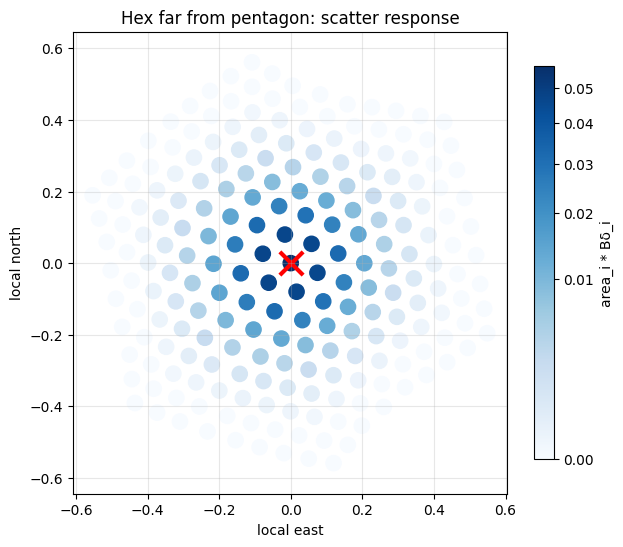

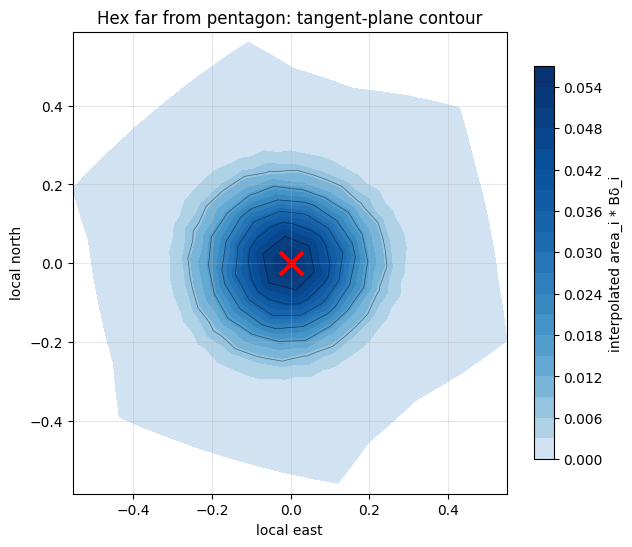

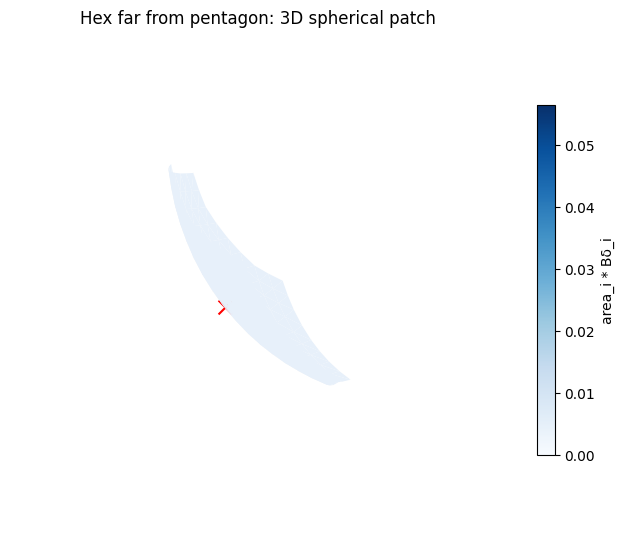

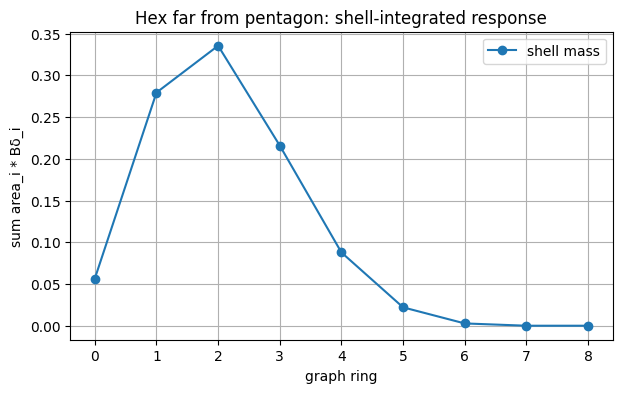

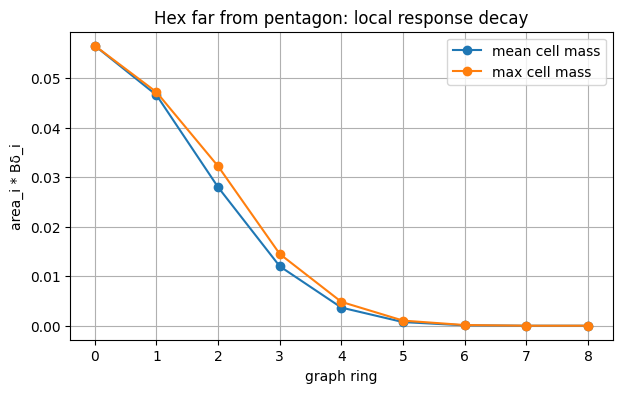


Hex adjacent to pentagon
cell: 642
degree: 6
distance to nearest pentagon: 1
lon/lat: -94.06362281596688 -55.005530573054266

Mass checks:
  integral_A(B delta) = 0.9999999999999817
  plotted mass        = 0.9999999999999818

Centroid shift in tangent plane:
  xc = 0.005630222015294254
  yc = -0.00880239326672328
  radius shift = 0.010448996466817252

Shape moments:
  lambda1 = 0.012022972513626969
  lambda2 = 0.011303344620229819
  anisotropy sqrt(lambda1/lambda2) = 1.0313413792398085

Ring shell mass:
  ring  0: 6.0066034932e-02
  ring  1: 2.7994556181e-01
  ring  2: 3.3019453271e-01
  ring  3: 2.1558233322e-01
  ring  4: 8.9025417728e-02
  ring  5: 2.2422561467e-02
  ring  6: 2.7635581295e-03
  ring  7: 0.0000000000e+00
  ring  8: 0.0000000000e+00


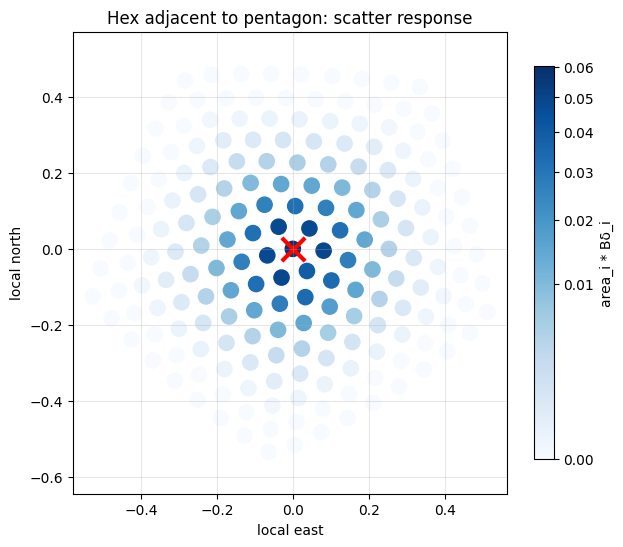

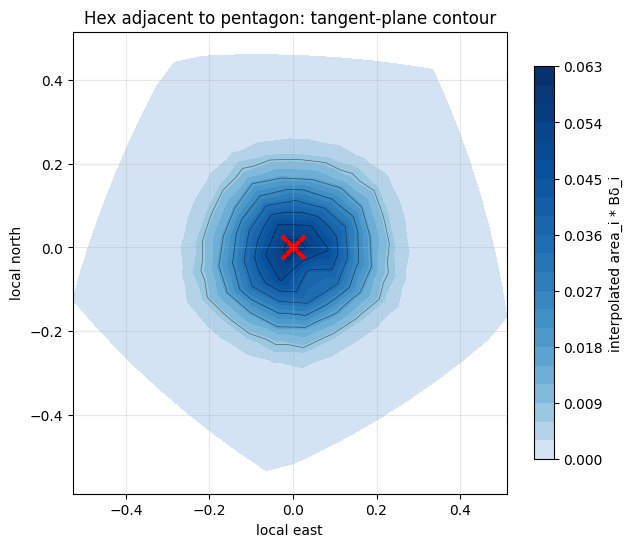

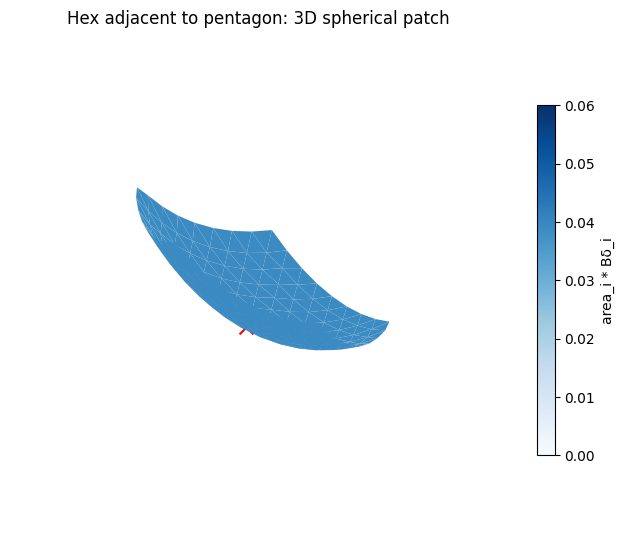

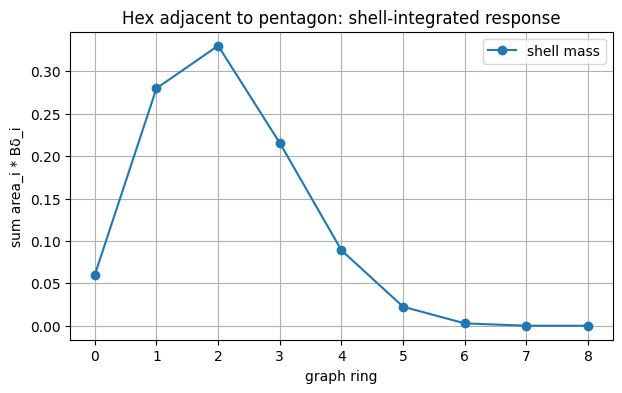

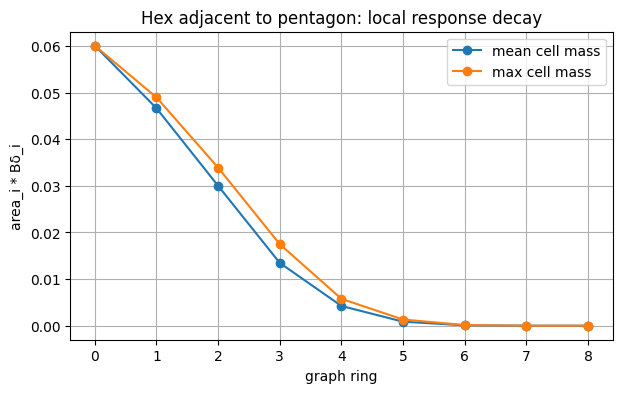


Pentagon impulse
cell: 0
degree: 5
distance to nearest pentagon: 0
lon/lat: 121.717474411461 0.0

Mass checks:
  integral_A(B delta) = 1.000000000000049
  plotted mass        = 1.0000000000000493

Centroid shift in tangent plane:
  xc = 6.938893903906886e-18
  yc = -6.938893903906886e-18
  radius shift = 9.813077866773111e-18

Shape moments:
  lambda1 = 0.010902494335999737
  lambda2 = 0.010902494335999728
  anisotropy sqrt(lambda1/lambda2) = 1.0000000000000004

Ring shell mass:
  ring  0: 4.9727395303e-02
  ring  1: 2.6870747963e-01
  ring  2: 3.3567786541e-01
  ring  3: 2.2490045583e-01
  ring  4: 9.4053972225e-02
  ring  5: 2.3971286358e-02
  ring  6: 2.9615452385e-03
  ring  7: 0.0000000000e+00
  ring  8: 0.0000000000e+00


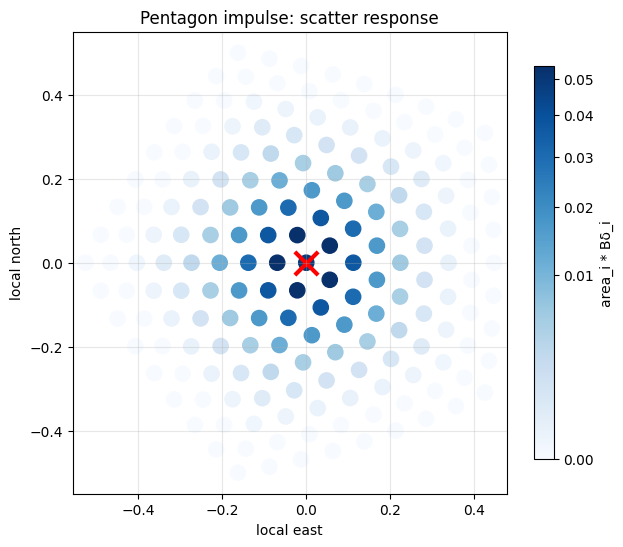

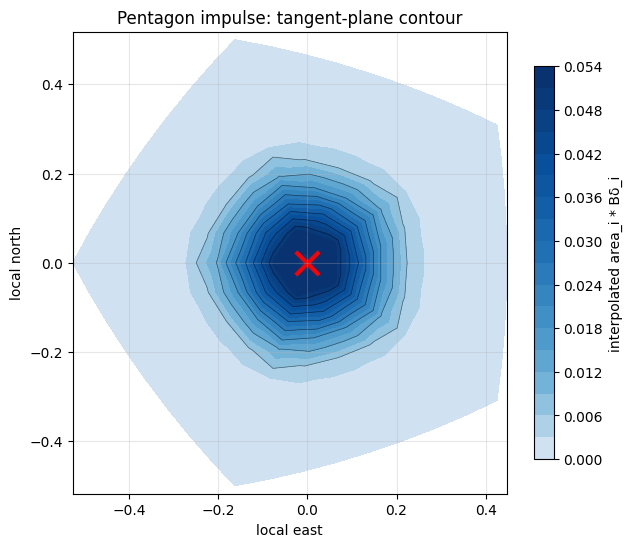

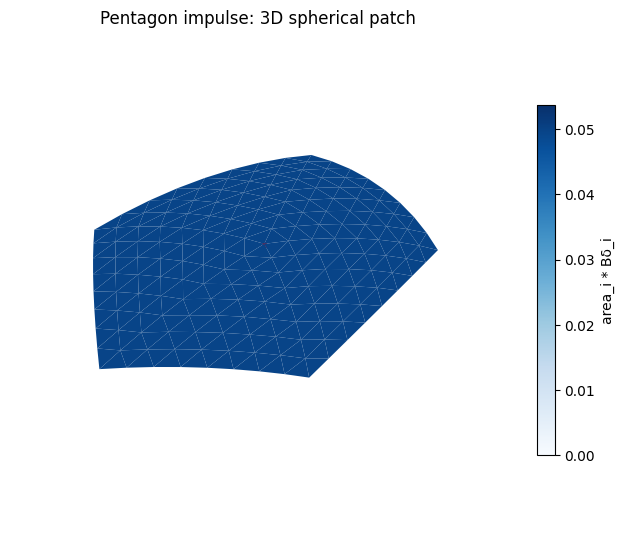

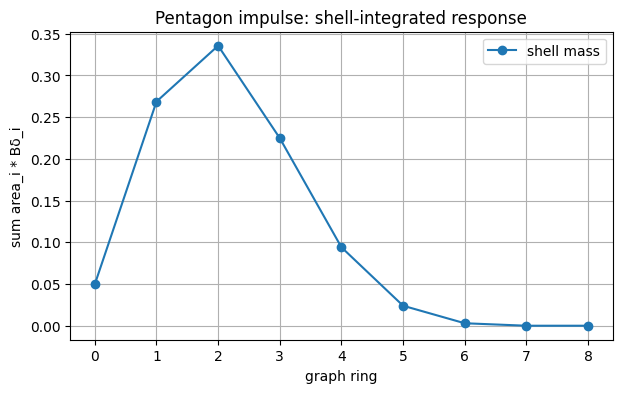

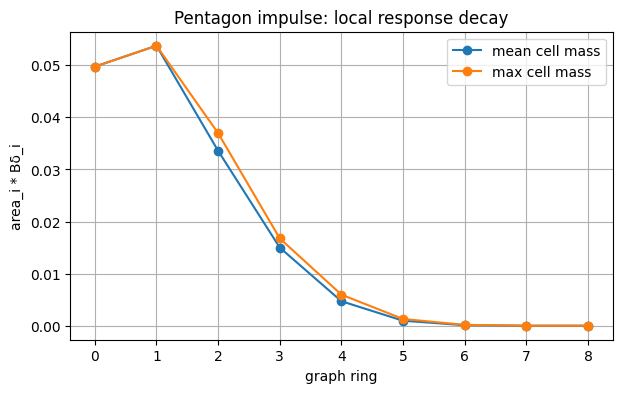

In [ ]:
import numpy as np
import scipy.sparse as sp
import matplotlib.pyplot as plt
import matplotlib.tri as mtri

from matplotlib.colors import PowerNorm
from mpl_toolkits.mplot3d import Axes3D

# ============================================================
# Configuration
# ============================================================

GRID_FILE = "/content/drive/MyDrive/GLOBAL_SW_FV/grid/global_hex_ico_grid_v0.npz"

R_SUPPORT = 3
SIGMA_R = 1.25
SINKHORN_ITERS = 500
SINKHORN_TOL = 1e-13

MAX_PLOT_RING = 8
POINT_SIZE = 120

#CMAP = "Greys"
#CMAP = "YlOrRd"
CMAP = "Blues"

GAMMA = 0.45

# ============================================================
# Load grid
# ============================================================

grid = np.load(GRID_FILE, allow_pickle=True)

area = grid["cell_area"].astype(np.float64)
xyz = grid["cell_center_xyz"].astype(np.float64)
faces = grid["primal_faces"].astype(np.int64)

lon_raw = grid["cell_center_lon"].astype(np.float64)
lat_raw = grid["cell_center_lat"].astype(np.float64)

if np.max(np.abs(lon_raw)) <= 2.0 * np.pi + 1e-6:
    lon = np.rad2deg(lon_raw)
    lat = np.rad2deg(lat_raw)
else:
    lon = lon_raw
    lat = lat_raw

ncells = area.size

print("Number of cells:", ncells)
print("Area min/max:", area.min(), area.max())
print("Total area:", area.sum())
print("lon range:", lon.min(), lon.max())
print("lat range:", lat.min(), lat.max())

# ============================================================
# Neighbor graph
# ============================================================

def build_neighbors_from_primal_faces(faces, ncells):
    neigh = [set() for _ in range(ncells)]

    for tri in faces:
        tri = tri[tri >= 0]
        if len(tri) != 3:
            continue

        a, b, c = tri
        neigh[a].add(b); neigh[a].add(c)
        neigh[b].add(a); neigh[b].add(c)
        neigh[c].add(a); neigh[c].add(b)

    return [sorted(s) for s in neigh]

neighbors = build_neighbors_from_primal_faces(faces, ncells)
deg = np.array([len(n) for n in neighbors])

print("Degree counts:", {int(d): int(np.sum(deg == d)) for d in sorted(set(deg))})

# ============================================================
# Graph utilities
# ============================================================

def graph_rings_for_cell(i, neighbors, R):
    visited = {i}
    rings = [[i]]
    frontier = [i]

    for r in range(1, R + 1):
        new_frontier = []

        for q in frontier:
            for j in neighbors[q]:
                if j not in visited:
                    visited.add(j)
                    new_frontier.append(j)

        rings.append(new_frontier)
        frontier = new_frontier

    return rings


def graph_distance_from_sources(sources, neighbors):
    dist = -np.ones(len(neighbors), dtype=np.int64)
    frontier = []

    for s in sources:
        dist[s] = 0
        frontier.append(s)

    while frontier:
        new_frontier = []

        for q in frontier:
            for j in neighbors[q]:
                if dist[j] < 0:
                    dist[j] = dist[q] + 1
                    new_frontier.append(j)

        frontier = new_frontier

    return dist


def graph_distance_from_cell(i0, neighbors, max_r=None):
    dist = -np.ones(len(neighbors), dtype=np.int64)
    dist[i0] = 0
    frontier = [i0]

    while frontier:
        new_frontier = []

        for q in frontier:
            if max_r is not None and dist[q] >= max_r:
                continue

            for j in neighbors[q]:
                if dist[j] < 0:
                    dist[j] = dist[q] + 1
                    new_frontier.append(j)

        frontier = new_frontier

    return dist

# ============================================================
# Build self-adjoint graph smoother
# ============================================================

rows, cols, vals = [], [], []

for i in range(ncells):
    rings = graph_rings_for_cell(i, neighbors, R_SUPPORT)

    for r, ring in enumerate(rings):
        wr = np.exp(-0.5 * (r / SIGMA_R) ** 2)

        for j in ring:
            rows.append(i)
            cols.append(j)
            vals.append(wr)

K0 = sp.coo_matrix((vals, (rows, cols)), shape=(ncells, ncells)).tocsr()
K0 = 0.5 * (K0 + K0.T)

d = np.ones(ncells, dtype=np.float64)

for it in range(SINKHORN_ITERS):
    Kd = K0 @ d
    row_sum = d * Kd
    ratio = area / np.maximum(row_sum, 1e-300)
    err = np.max(np.abs(ratio - 1.0))

    d *= np.sqrt(ratio)

    if it % 50 == 0:
        print(f"Sinkhorn iter {it:4d}: max ratio error = {err:.3e}")

    if err < SINKHORN_TOL:
        print(f"Sinkhorn converged at iter {it}: error = {err:.3e}")
        break

K = sp.diags(d) @ K0 @ sp.diags(d)
K = K.tocsr()

row_sum = np.asarray(K @ np.ones(ncells)).ravel()
print("K row-sum/area max relative error:",
      np.max(np.abs(row_sum - area)) / np.mean(area))

def S_apply(x):
    return (K @ x) / area

def B_apply(x):
    return S_apply(S_apply(x))

def integral_A(x):
    return np.sum(area * x)

def inner_A(x, y):
    return np.sum(area * x * y)

# ============================================================
# Select three impulse cases
# ============================================================

pentagons = np.where(deg == 5)[0]
hexagons = np.where(deg == 6)[0]

dist_to_pent = graph_distance_from_sources(pentagons, neighbors)

# Case 1: hexagon farthest from any pentagon
i_hex_far = int(hexagons[np.argmax(dist_to_pent[hexagons])])

# Case 2: hexagon adjacent to a pentagon
near_hex_candidates = hexagons[dist_to_pent[hexagons] == 1]
i_hex_near = int(near_hex_candidates[0])

# Case 3: pentagon itself
i_pent = int(pentagons[0])

cases = [
    ("Hex far from pentagon", i_hex_far),
    ("Hex adjacent to pentagon", i_hex_near),
    ("Pentagon impulse", i_pent),
]

print("\nSelected impulse cases:")
for name, i0 in cases:
    print(f"{name:28s}: cell={i0:5d}, degree={deg[i0]}, "
          f"dist_to_pent={dist_to_pent[i0]}, lon={lon[i0]:8.3f}, lat={lat[i0]:8.3f}")

# ============================================================
# Impulse response
# ============================================================

def compute_response(i0):
    delta = np.zeros(ncells)
    delta[i0] = 1.0 / area[i0]

    adjoint = S_apply(delta)
    response = S_apply(adjoint)

    dist = graph_distance_from_cell(i0, neighbors, max_r=MAX_PLOT_RING)

    return delta, adjoint, response, dist

# ============================================================
# Tangent plane coordinates
# ============================================================

def tangent_coordinates(i0, mask):
    x0 = xyz[i0].astype(np.float64)
    x0 = x0 / np.linalg.norm(x0)

    zaxis = np.array([0.0, 0.0, 1.0])
    east = np.cross(zaxis, x0)

    if np.linalg.norm(east) < 1e-12:
        east = np.array([1.0, 0.0, 0.0])
    else:
        east = east / np.linalg.norm(east)

    north = np.cross(x0, east)
    north = north / np.linalg.norm(north)

    X = xyz[mask].astype(np.float64)
    X = X / np.linalg.norm(X, axis=1)[:, None]

    dx = X - x0[None, :]

    xe = dx @ east
    yn = dx @ north

    return xe, yn

# ============================================================
# Local triangulation for contour plots
# ============================================================

def local_triangulation(mask, xe, yn):
    global_ids = np.where(mask)[0]
    local_id = {g: k for k, g in enumerate(global_ids)}

    local_tris = []

    for tri in faces:
        a, b, c = tri
        if a in local_id and b in local_id and c in local_id:
            local_tris.append([local_id[a], local_id[b], local_id[c]])

    local_tris = np.array(local_tris, dtype=np.int64)

    return mtri.Triangulation(xe, yn, local_tris)

# ============================================================
# Diagnostics
# ============================================================

def anisotropy_diagnostics(i0, response, dist, label):
    mask = (dist >= 0) & (dist <= MAX_PLOT_RING)

    xe, yn = tangent_coordinates(i0, mask)
    mass = area[mask] * response[mask]

    total = np.sum(mass)
    xc = np.sum(mass * xe) / total
    yc = np.sum(mass * yn) / total

    X = np.vstack([xe - xc, yn - yc]).T
    C = (X.T * mass) @ X / total

    evals, evecs = np.linalg.eigh(C)
    evals = np.sort(evals)[::-1]

    anisotropy = np.sqrt(evals[0] / max(evals[1], 1e-300))

    print("\n============================================================")
    print(label)
    print("============================================================")
    print("cell:", i0)
    print("degree:", deg[i0])
    print("distance to nearest pentagon:", dist_to_pent[i0])
    print("lon/lat:", lon[i0], lat[i0])
    print()
    print("Mass checks:")
    print("  integral_A(B delta) =", integral_A(response))
    print("  plotted mass        =", total)
    print()
    print("Centroid shift in tangent plane:")
    print("  xc =", xc)
    print("  yc =", yc)
    print("  radius shift =", np.sqrt(xc**2 + yc**2))
    print()
    print("Shape moments:")
    print("  lambda1 =", evals[0])
    print("  lambda2 =", evals[1])
    print("  anisotropy sqrt(lambda1/lambda2) =", anisotropy)
    print()
    print("Ring shell mass:")
    for r in range(MAX_PLOT_RING + 1):
        m = dist == r
        if np.any(m):
            print(f"  ring {r:2d}: {np.sum(area[m] * response[m]):.10e}")

# ============================================================
# Plots
# ============================================================

def plot_scatter_response(i0, response, dist, label):
    mask = (dist >= 0) & (dist <= MAX_PLOT_RING)

    xe, yn = tangent_coordinates(i0, mask)
    mass = area[mask] * response[mask]

    plt.figure(figsize=(7, 6))
    sc = plt.scatter(
        xe, yn,
        c=mass,
        s=POINT_SIZE,
        cmap=CMAP,
        norm=PowerNorm(gamma=GAMMA)
    )

    plt.scatter([0], [0], marker="x", s=280, c="red", linewidths=3)

    plt.colorbar(sc, shrink=0.85, label="area_i * Bδ_i")
    plt.xlabel("local east")
    plt.ylabel("local north")
    plt.title(label + ": scatter response")
    plt.axis("equal")
    plt.grid(True, alpha=0.3)
    plt.show()


def plot_contour_response(i0, response, dist, label):
    mask = (dist >= 0) & (dist <= MAX_PLOT_RING)

    xe, yn = tangent_coordinates(i0, mask)
    mass = area[mask] * response[mask]

    tri = local_triangulation(mask, xe, yn)

    plt.figure(figsize=(7, 6))
    cf = plt.tricontourf(
        tri,
        mass,
        levels=20,
        cmap=CMAP,
        norm=PowerNorm(gamma=GAMMA)
    )

    plt.tricontour(
        tri,
        mass,
        levels=8,
        colors="k",
        linewidths=0.5,
        alpha=0.5
    )

    plt.scatter([0], [0], marker="x", s=280, c="red", linewidths=3)

    plt.colorbar(cf, shrink=0.85, label="interpolated area_i * Bδ_i")
    plt.xlabel("local east")
    plt.ylabel("local north")
    plt.title(label + ": tangent-plane contour")
    plt.axis("equal")
    plt.grid(True, alpha=0.3)
    plt.show()


def plot_3d_patch(i0, response, dist, label):
    mask = (dist >= 0) & (dist <= MAX_PLOT_RING)

    global_ids = np.where(mask)[0]
    local_id = {g: k for k, g in enumerate(global_ids)}

    local_tris = []

    for tri in faces:
        a, b, c = tri
        if a in local_id and b in local_id and c in local_id:
            local_tris.append([local_id[a], local_id[b], local_id[c]])

    local_tris = np.array(local_tris, dtype=np.int64)

    X = xyz[mask].copy()
    r = np.linalg.norm(X, axis=1)
    X = X / r[:, None]

    mass = area[mask] * response[mask]

    fig = plt.figure(figsize=(8, 7))
    ax = fig.add_subplot(111, projection="3d")

    surf = ax.plot_trisurf(
        X[:, 0],
        X[:, 1],
        X[:, 2],
        triangles=local_tris,
        cmap=CMAP,
        linewidth=0.2,
        antialiased=True,
        shade=False
    )

    surf.set_array(mass)
    surf.set_clim(mass.min(), mass.max())

    ax.scatter(
        [X[global_ids == i0, 0][0]],
        [X[global_ids == i0, 1][0]],
        [X[global_ids == i0, 2][0]],
        c="red",
        s=100,
        marker="x"
    )

    fig.colorbar(surf, ax=ax, shrink=0.65, label="area_i * Bδ_i")

    ax.set_title(label + ": 3D spherical patch")
    ax.set_box_aspect([1, 1, 1])
    ax.set_axis_off()

    plt.show()


def plot_radial_response(response, dist, label):
    rings = []
    shell_mass = []
    mean_cell_mass = []
    max_cell_mass = []

    for r in range(MAX_PLOT_RING + 1):
        m = dist == r
        if not np.any(m):
            continue

        cell_mass = area[m] * response[m]

        rings.append(r)
        shell_mass.append(np.sum(cell_mass))
        mean_cell_mass.append(np.mean(cell_mass))
        max_cell_mass.append(np.max(cell_mass))

    plt.figure(figsize=(7, 4))
    plt.plot(rings, shell_mass, "o-", label="shell mass")
    plt.xlabel("graph ring")
    plt.ylabel("sum area_i * Bδ_i")
    plt.title(label + ": shell-integrated response")
    plt.grid(True)
    plt.legend()
    plt.show()

    plt.figure(figsize=(7, 4))
    plt.plot(rings, mean_cell_mass, "o-", label="mean cell mass")
    plt.plot(rings, max_cell_mass, "o-", label="max cell mass")
    plt.xlabel("graph ring")
    plt.ylabel("area_i * Bδ_i")
    plt.title(label + ": local response decay")
    plt.grid(True)
    plt.legend()
    plt.show()

# ============================================================
# Run all cases
# ============================================================

responses = {}

for label, i0 in cases:
    delta, adjoint, response, dist = compute_response(i0)
    responses[label] = (i0, delta, adjoint, response, dist)

    anisotropy_diagnostics(i0, response, dist, label)

    plot_scatter_response(i0, response, dist, label)
    plot_contour_response(i0, response, dist, label)
    plot_3d_patch(i0, response, dist, label)
    plot_radial_response(response, dist, label)

# test_global_level0_covariance_radius_v0.py

**TEST:**

1. effective radius
2. anisotropy
3. centroid shift
4. mass error
5. distance to nearest pentagon



ncells: 2562
area min/max: 134536555820.17395 238195365847.2499
degree counts: {5: 12, 6: 2550}
K0 nnz: 94422
Sinkhorn iter    0: err=2.455e+10
Sinkhorn converged at iter 41: err=9.970e-14
row-sum/area relative error: 3.433382122534929e-14
B nnz: 320922
processed 0/2562
processed 500/2562
processed 1000/2562
processed 1500/2562
processed 2000/2562
processed 2500/2562

GLOBAL LEVEL-0 COVARIANCE DIAGNOSTICS
radius            : min=1.48705699e-01, mean=1.67033081e-01, std=4.20498784e-03, max=1.73390626e-01
anisotropy        : min=1.00000000e+00, mean=1.06840883e+00, std=2.51575575e-02, max=1.11613025e+00
centroid_shift    : min=1.89080826e-18, mean=6.82592318e-03, std=3.88683734e-03, max=1.49089222e-02
mass_error        : min=0.00000000e+00, mean=3.03920303e-15, std=5.21518935e-15, max=4.95159469e-14
peak_mass         : min=5.16733167e-02, mean=5.48216583e-02, std=1.97742676e-03, max=6.00660349e-02
support_count     : min=1.06000000e+02, mean=1.25262295e+02, std=3.53391827e+00, max=1.2700

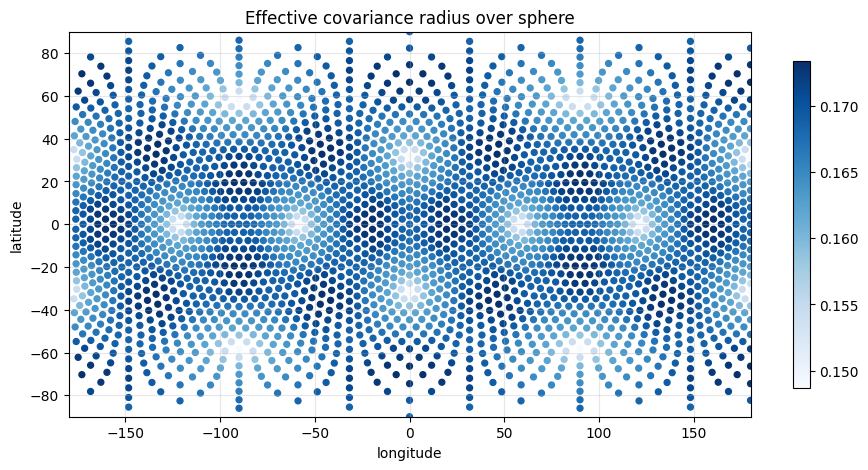

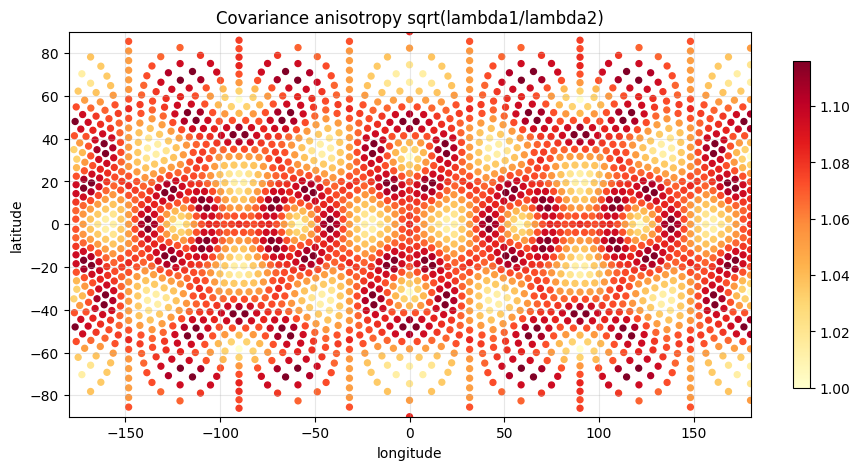

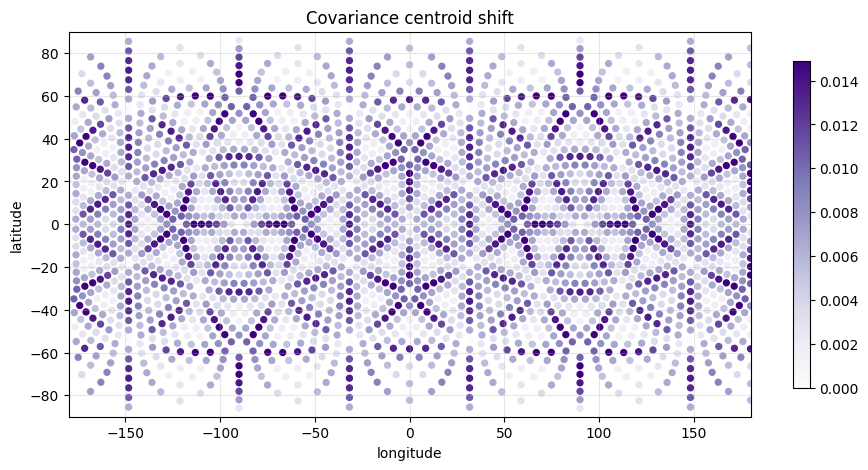

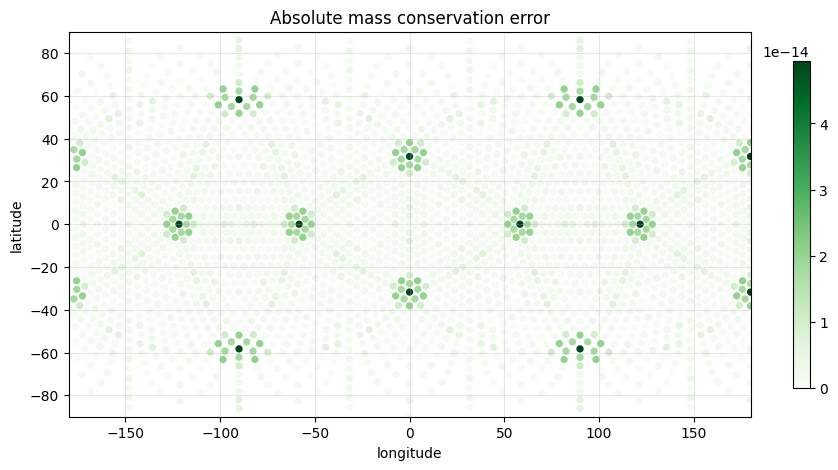

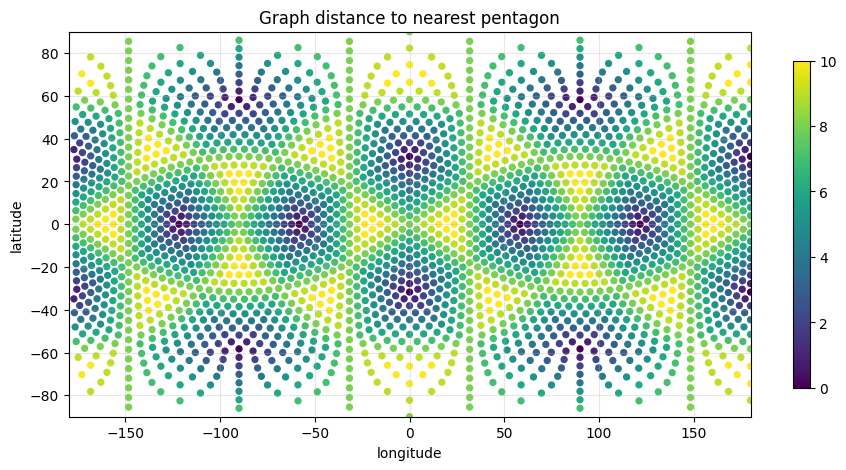

...

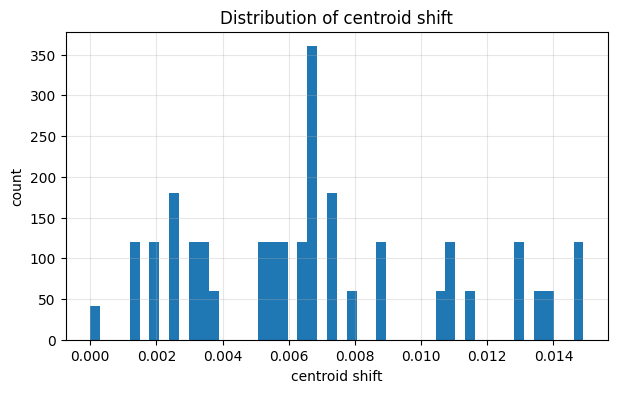

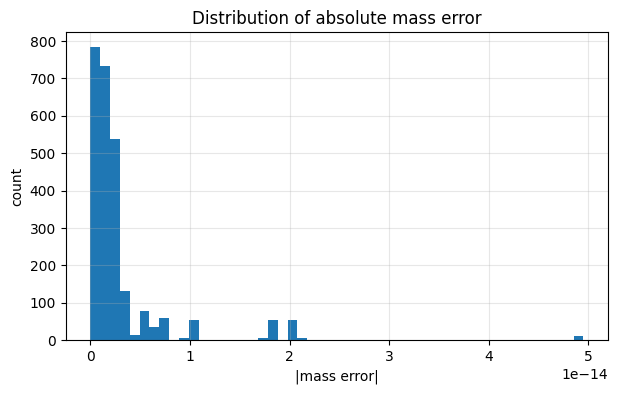

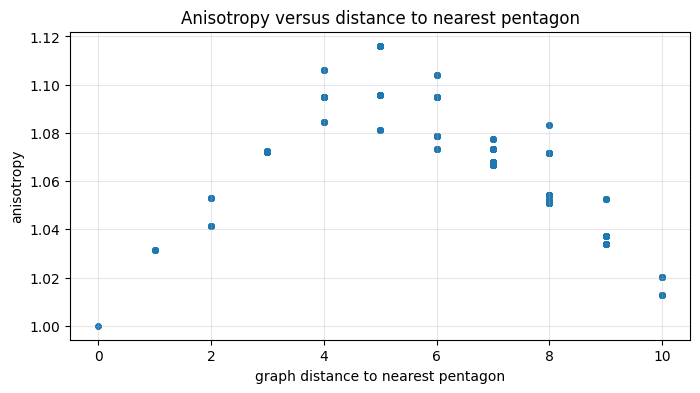

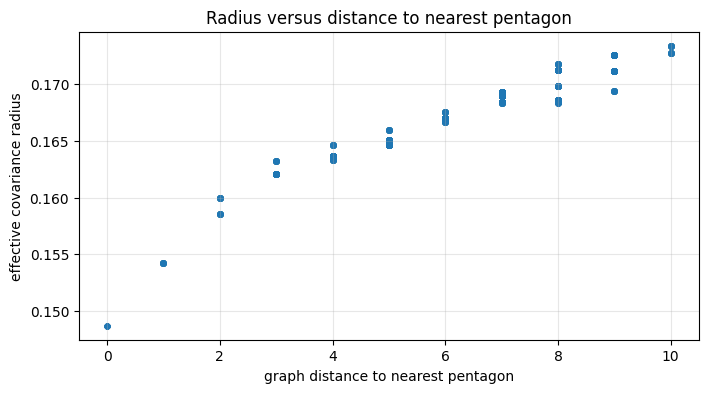

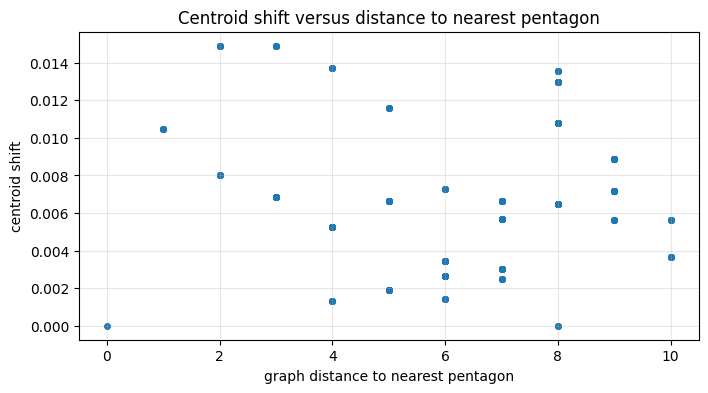

In [3]:
import numpy as np
import scipy.sparse as sp
import matplotlib.pyplot as plt
from matplotlib.colors import PowerNorm

GRID_FILE = "/content/drive/MyDrive/GLOBAL_SW_FV/grid/global_hex_ico_grid_v0.npz"

R_SUPPORT = 3
SIGMA_R = 1.25
SINKHORN_ITERS = 500
SINKHORN_TOL = 1e-13

OUT_NPZ = "/content/graph_mgbf_level0_global_radius_v0.npz"

# ============================================================
# Load grid
# ============================================================

grid = np.load(GRID_FILE, allow_pickle=True)

area = grid["cell_area"].astype(np.float64)
xyz = grid["cell_center_xyz"].astype(np.float64)
faces = grid["primal_faces"].astype(np.int64)

lon_raw = grid["cell_center_lon"].astype(np.float64)
lat_raw = grid["cell_center_lat"].astype(np.float64)

if np.max(np.abs(lon_raw)) <= 2*np.pi + 1e-6:
    lon = np.rad2deg(lon_raw)
    lat = np.rad2deg(lat_raw)
else:
    lon = lon_raw
    lat = lat_raw

ncells = area.size
xyz_unit = xyz / np.linalg.norm(xyz, axis=1)[:, None]

print("ncells:", ncells)
print("area min/max:", area.min(), area.max())

# ============================================================
# Neighbor graph
# ============================================================

def build_neighbors_from_primal_faces(faces, ncells):
    neigh = [set() for _ in range(ncells)]
    for tri in faces:
        tri = tri[tri >= 0]
        if len(tri) != 3:
            continue
        a, b, c = tri
        neigh[a].add(b); neigh[a].add(c)
        neigh[b].add(a); neigh[b].add(c)
        neigh[c].add(a); neigh[c].add(b)
    return [sorted(s) for s in neigh]

neighbors = build_neighbors_from_primal_faces(faces, ncells)
deg = np.array([len(n) for n in neighbors])

pentagons = np.where(deg == 5)[0]
hexagons = np.where(deg == 6)[0]

print("degree counts:", {int(d): int(np.sum(deg == d)) for d in sorted(set(deg))})

def graph_rings_for_cell(i, neighbors, R):
    visited = {i}
    rings = [[i]]
    frontier = [i]

    for r in range(1, R + 1):
        new_frontier = []
        for q in frontier:
            for j in neighbors[q]:
                if j not in visited:
                    visited.add(j)
                    new_frontier.append(j)
        rings.append(new_frontier)
        frontier = new_frontier

    return rings

def graph_distance_from_sources(sources, neighbors):
    dist = -np.ones(len(neighbors), dtype=np.int64)
    frontier = []
    for s in sources:
        dist[s] = 0
        frontier.append(s)

    while frontier:
        new_frontier = []
        for q in frontier:
            for j in neighbors[q]:
                if dist[j] < 0:
                    dist[j] = dist[q] + 1
                    new_frontier.append(j)
        frontier = new_frontier

    return dist

dist_to_pent = graph_distance_from_sources(pentagons, neighbors)

# ============================================================
# Build Level-0 self-adjoint smoother
# ============================================================

rows, cols, vals = [], [], []

for i in range(ncells):
    rings = graph_rings_for_cell(i, neighbors, R_SUPPORT)
    for r, ring in enumerate(rings):
        wr = np.exp(-0.5 * (r / SIGMA_R)**2)
        for j in ring:
            rows.append(i)
            cols.append(j)
            vals.append(wr)

K0 = sp.coo_matrix((vals, (rows, cols)), shape=(ncells, ncells)).tocsr()
K0 = 0.5 * (K0 + K0.T)

print("K0 nnz:", K0.nnz)

d = np.ones(ncells)

for it in range(SINKHORN_ITERS):
    Kd = K0 @ d
    row_sum = d * Kd
    ratio = area / np.maximum(row_sum, 1e-300)
    err = np.max(np.abs(ratio - 1.0))
    d *= np.sqrt(ratio)

    if it % 50 == 0:
        print(f"Sinkhorn iter {it:4d}: err={err:.3e}")

    if err < SINKHORN_TOL:
        print(f"Sinkhorn converged at iter {it}: err={err:.3e}")
        break

K = sp.diags(d) @ K0 @ sp.diags(d)
K = K.tocsr()

row_sum = np.asarray(K @ np.ones(ncells)).ravel()
print("row-sum/area relative error:",
      np.max(np.abs(row_sum - area)) / np.mean(area))

Ainv = sp.diags(1.0 / area)
S = Ainv @ K

# Full one-level self-adjoint covariance filter:
# B = S S = direct(adjoint(.))
B = (S @ S).tocsc()

print("B nnz:", B.nnz)

# ============================================================
# Global impulse diagnostics
# ============================================================

radius = np.zeros(ncells)
anisotropy = np.zeros(ncells)
centroid_shift = np.zeros(ncells)
mass_error = np.zeros(ncells)
peak_mass = np.zeros(ncells)
support_count = np.zeros(ncells, dtype=np.int64)

for i0 in range(ncells):
    col_start = B.indptr[i0]
    col_end = B.indptr[i0 + 1]

    js = B.indices[col_start:col_end]
    vals_B = B.data[col_start:col_end]

    # response to unit-mass delta_i:
    # delta_i = 1/area_i at cell i
    response_j = vals_B / area[i0]
    mass_j = area[js] * response_j

    total_mass = np.sum(mass_j)
    mass_error[i0] = total_mass - 1.0
    peak_mass[i0] = np.max(mass_j)
    support_count[i0] = len(js)

    x0 = xyz_unit[i0]
    X = xyz_unit[js]

    cosang = np.clip(X @ x0, -1.0, 1.0)
    theta = np.arccos(cosang)

    radius[i0] = np.sqrt(np.sum(mass_j * theta**2) / total_mass)

    # tangent-plane anisotropy
    zaxis = np.array([0.0, 0.0, 1.0])
    east = np.cross(zaxis, x0)

    if np.linalg.norm(east) < 1e-12:
        east = np.array([1.0, 0.0, 0.0])
    else:
        east /= np.linalg.norm(east)

    north = np.cross(x0, east)
    north /= np.linalg.norm(north)

    dx = X - x0[None, :]
    xe = dx @ east
    yn = dx @ north

    xc = np.sum(mass_j * xe) / total_mass
    yc = np.sum(mass_j * yn) / total_mass
    centroid_shift[i0] = np.sqrt(xc**2 + yc**2)

    Y = np.vstack([xe - xc, yn - yc]).T
    C = (Y.T * mass_j) @ Y / total_mass
    evals = np.linalg.eigvalsh(C)
    evals = np.sort(evals)[::-1]

    anisotropy[i0] = np.sqrt(evals[0] / max(evals[1], 1e-300))

    if i0 % 500 == 0:
        print(f"processed {i0}/{ncells}")

# ============================================================
# Summary
# ============================================================

print("\n============================================================")
print("GLOBAL LEVEL-0 COVARIANCE DIAGNOSTICS")
print("============================================================")

def summarize(name, arr):
    print(f"{name:18s}: min={arr.min():.8e}, mean={arr.mean():.8e}, "
          f"std={arr.std():.8e}, max={arr.max():.8e}")

summarize("radius", radius)
summarize("anisotropy", anisotropy)
summarize("centroid_shift", centroid_shift)
summarize("mass_error", np.abs(mass_error))
summarize("peak_mass", peak_mass)
summarize("support_count", support_count.astype(float))

print("\nBy distance to nearest pentagon:")
for d0 in sorted(set(dist_to_pent)):
    m = dist_to_pent == d0
    print(f"dist={d0:2d}, n={np.sum(m):5d}, "
          f"radius mean={radius[m].mean():.8e}, "
          f"anis mean={anisotropy[m].mean():.8e}, "
          f"anis max={anisotropy[m].max():.8e}, "
          f"shift mean={centroid_shift[m].mean():.8e}")

imax_anis = int(np.argmax(anisotropy))
imax_shift = int(np.argmax(centroid_shift))
imin_rad = int(np.argmin(radius))
imax_rad = int(np.argmax(radius))

print("\nExtremes:")
print("max anisotropy:", imax_anis, anisotropy[imax_anis],
      "deg", deg[imax_anis], "dist_to_pent", dist_to_pent[imax_anis],
      "lon/lat", lon[imax_anis], lat[imax_anis])

print("max shift:", imax_shift, centroid_shift[imax_shift],
      "deg", deg[imax_shift], "dist_to_pent", dist_to_pent[imax_shift],
      "lon/lat", lon[imax_shift], lat[imax_shift])

print("min radius:", imin_rad, radius[imin_rad],
      "deg", deg[imin_rad], "dist_to_pent", dist_to_pent[imin_rad],
      "lon/lat", lon[imin_rad], lat[imin_rad])

print("max radius:", imax_rad, radius[imax_rad],
      "deg", deg[imax_rad], "dist_to_pent", dist_to_pent[imax_rad],
      "lon/lat", lon[imax_rad], lat[imax_rad])

# ============================================================
# Save diagnostics
# ============================================================

np.savez(
    OUT_NPZ,
    lon=lon,
    lat=lat,
    area=area,
    deg=deg,
    dist_to_pent=dist_to_pent,
    radius=radius,
    anisotropy=anisotropy,
    centroid_shift=centroid_shift,
    mass_error=mass_error,
    peak_mass=peak_mass,
    support_count=support_count,
    R_SUPPORT=R_SUPPORT,
    SIGMA_R=SIGMA_R,
)

print("\nSaved:", OUT_NPZ)

# ============================================================
# Plots
# ============================================================

def scatter_global(field, title, cmap="viridis", point_size=18):
    plt.figure(figsize=(11, 5))
    sc = plt.scatter(lon, lat, c=field, s=point_size, cmap=cmap)
    plt.colorbar(sc, shrink=0.85)
    plt.xlabel("longitude")
    plt.ylabel("latitude")
    plt.title(title)
    plt.grid(True, alpha=0.3)
    plt.xlim(-180, 180)
    plt.ylim(-90, 90)
    plt.show()

def hist_plot(field, title, xlabel, bins=50):
    plt.figure(figsize=(7, 4))
    plt.hist(field, bins=bins)
    plt.xlabel(xlabel)
    plt.ylabel("count")
    plt.title(title)
    plt.grid(True, alpha=0.3)
    plt.show()

scatter_global(radius, "Effective covariance radius over sphere", cmap="Blues")
scatter_global(anisotropy, "Covariance anisotropy sqrt(lambda1/lambda2)", cmap="YlOrRd")
scatter_global(centroid_shift, "Covariance centroid shift", cmap="Purples")
scatter_global(np.abs(mass_error), "Absolute mass conservation error", cmap="Greens")
scatter_global(dist_to_pent, "Graph distance to nearest pentagon", cmap="viridis")

hist_plot(radius, "Distribution of effective covariance radius", "radius")
hist_plot(anisotropy, "Distribution of covariance anisotropy", "anisotropy")
hist_plot(centroid_shift, "Distribution of centroid shift", "centroid shift")
hist_plot(np.abs(mass_error), "Distribution of absolute mass error", "|mass error|")

# Box/scatter versus distance to nearest pentagon
plt.figure(figsize=(8, 4))
plt.scatter(dist_to_pent, anisotropy, s=12, alpha=0.5)
plt.xlabel("graph distance to nearest pentagon")
plt.ylabel("anisotropy")
plt.title("Anisotropy versus distance to nearest pentagon")
plt.grid(True, alpha=0.3)
plt.show()

plt.figure(figsize=(8, 4))
plt.scatter(dist_to_pent, radius, s=12, alpha=0.5)
plt.xlabel("graph distance to nearest pentagon")
plt.ylabel("effective covariance radius")
plt.title("Radius versus distance to nearest pentagon")
plt.grid(True, alpha=0.3)
plt.show()

plt.figure(figsize=(8, 4))
plt.scatter(dist_to_pent, centroid_shift, s=12, alpha=0.5)
plt.xlabel("graph distance to nearest pentagon")
plt.ylabel("centroid shift")
plt.title("Centroid shift versus distance to nearest pentagon")
plt.grid(True, alpha=0.3)
plt.show()

In [ ]:
# test_level0_spectral_response.py



1. Loads grid/operators.
2. Builds graph Laplacian.
3. Computes first 50 eigenpairs.
4. Applies B to each eigenvector.
5. Computes μₖ and εₖ.
6. Produces:
* transfer-function plots,
* eigenvector maps,
* diagnostic table.








ncells: 2562
area min/max: 134536555820.17395 238195365847.2499
degree counts: {5: 12, 6: 2550}
K0 nnz: 94422
Sinkhorn iter    0: err=2.455e+10
Sinkhorn converged at iter 41: err=9.970e-14
K row-sum/area relative error: 3.433382122534929e-14
L nnz: 17922
Computing eigenpairs...
Eigenvalues:
  k=  0, lambda=-6.512997583153e-27, norm_A=1.000000e+00
  k=  1, lambda=8.523013725850e-14, norm_A=1.000000e+00
  k=  2, lambda=8.523013725850e-14, norm_A=1.000000e+00
  k=  3, lambda=8.523013725851e-14, norm_A=1.000000e+00
  k=  4, lambda=2.550129296254e-13, norm_A=1.000000e+00
  k=  5, lambda=2.550129296254e-13, norm_A=1.000000e+00
  k=  6, lambda=2.550129296254e-13, norm_A=1.000000e+00
  k=  7, lambda=2.550129296254e-13, norm_A=1.000000e+00
  k=  8, lambda=2.550129296254e-13, norm_A=1.000000e+00
  k=  9, lambda=4.882911292286e-13, norm_A=1.000000e+00

LEVEL-0 SPECTRAL RESPONSE
 k        lambda              mu=gain           eps
  0   -6.5129975832e-27    1.0000000000e+00    5.7515e-15
  1    8.5

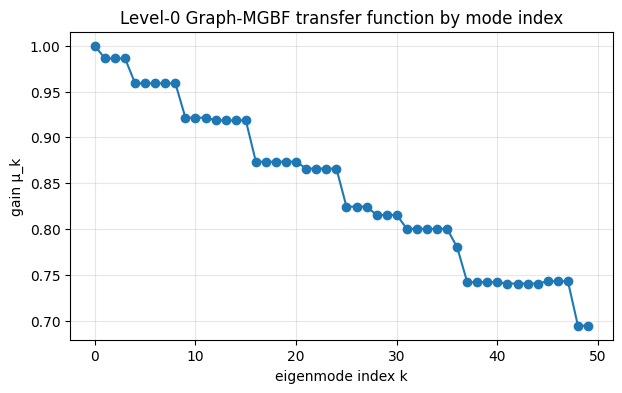

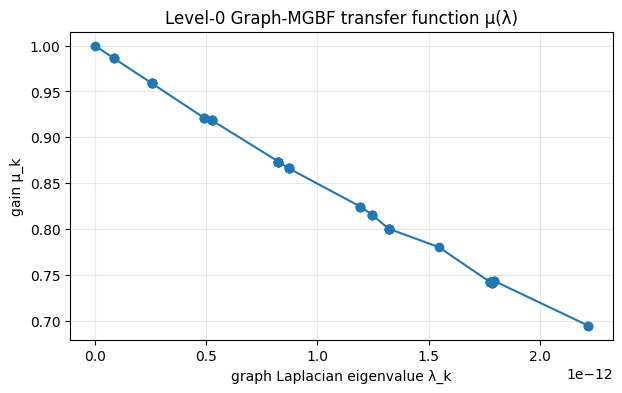

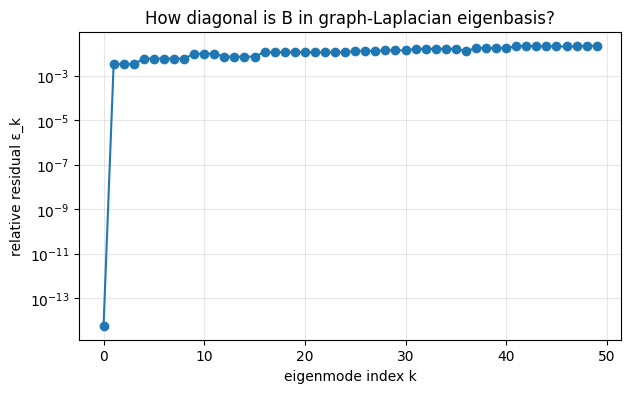

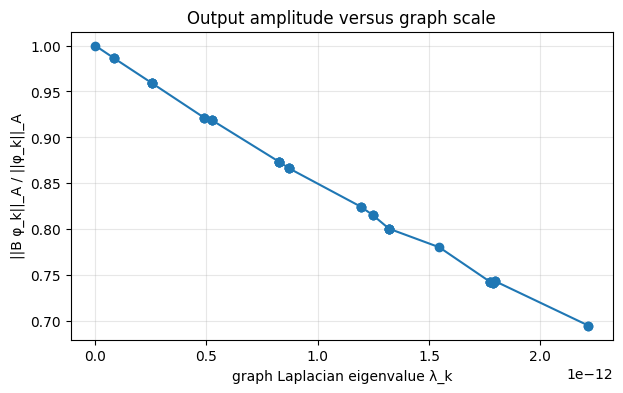

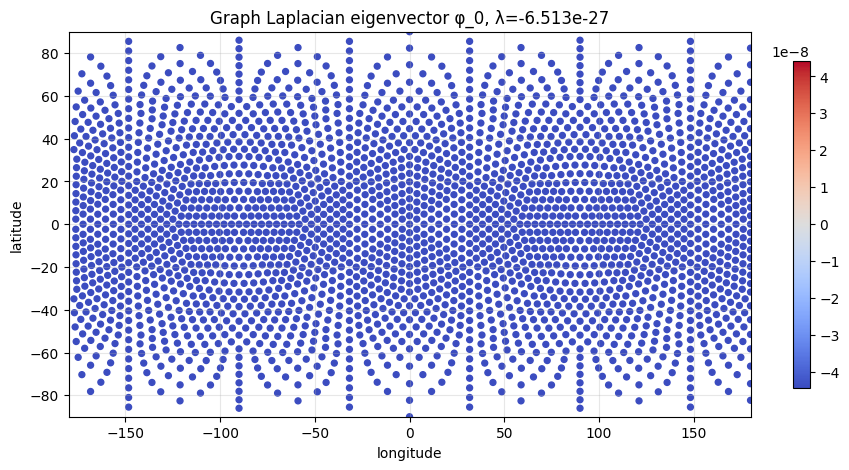

...

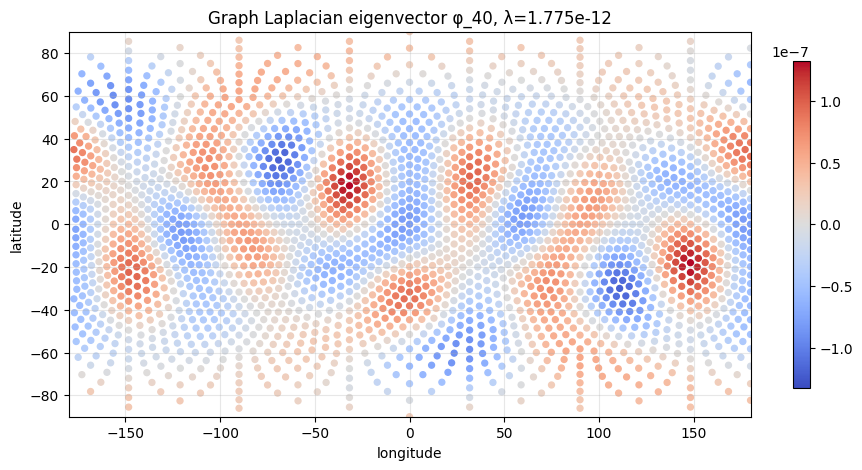

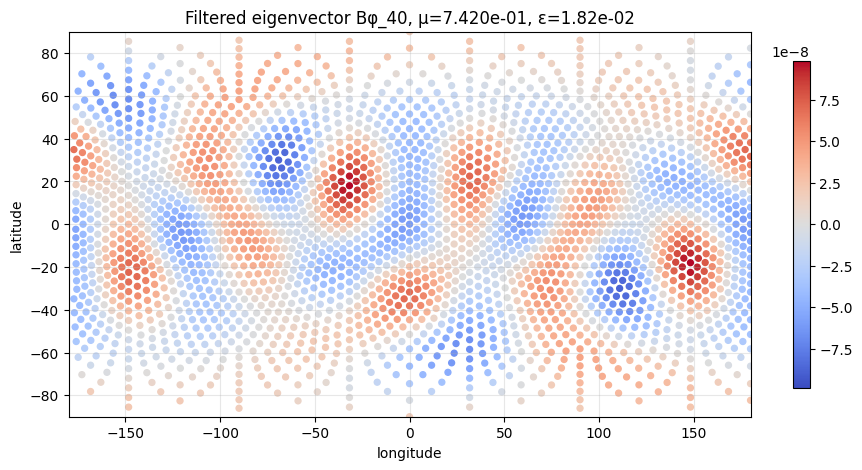

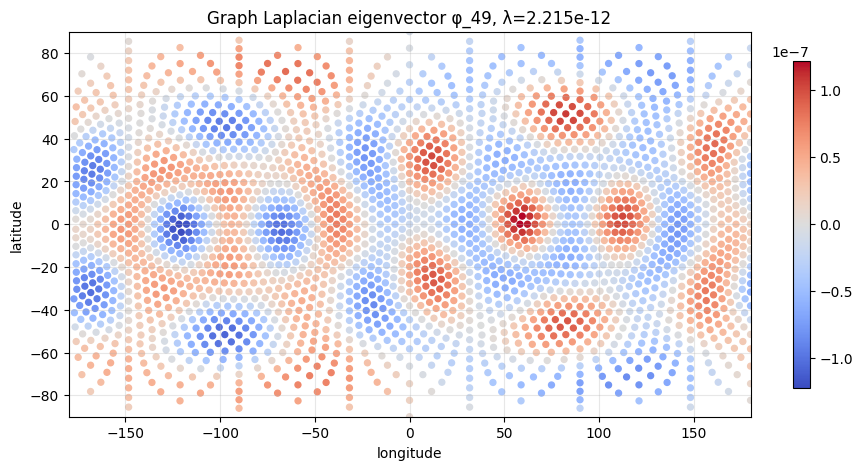

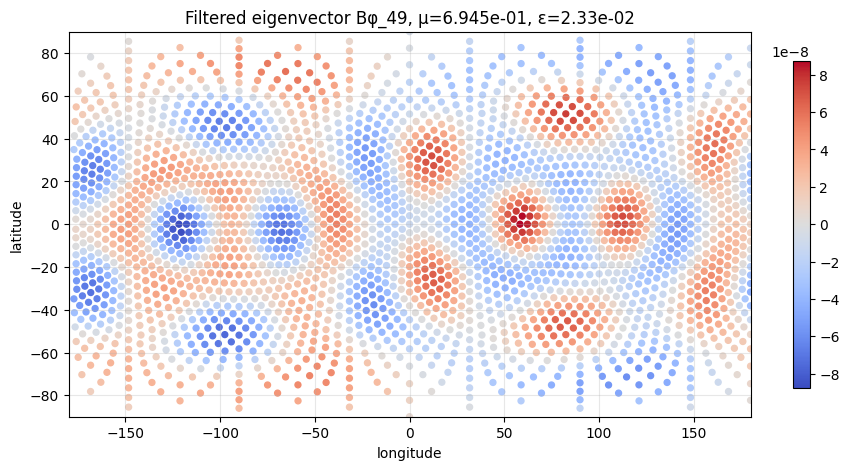

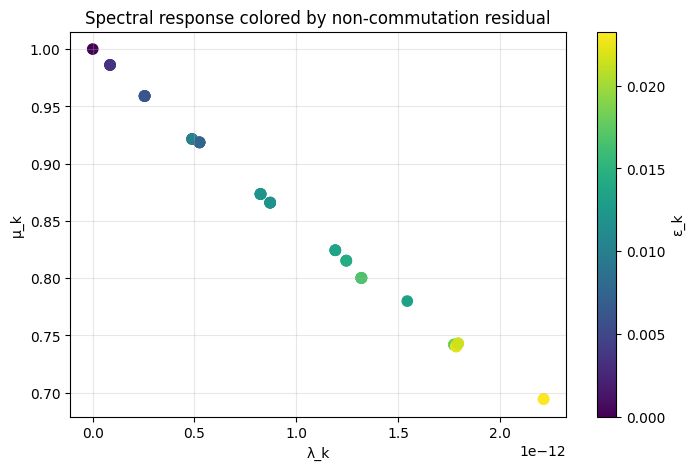

In [4]:
import numpy as np
import scipy.sparse as sp
import scipy.sparse.linalg as spla
import matplotlib.pyplot as plt

# ============================================================
# Configuration
# ============================================================

GRID_FILE = "/content/drive/MyDrive/GLOBAL_SW_FV/grid/global_hex_ico_grid_v0.npz"

R_SUPPORT = 3
SIGMA_R = 1.25
SINKHORN_ITERS = 500
SINKHORN_TOL = 1e-13

NEIG = 50
OUT_NPZ = "/content/graph_mgbf_level0_spectral_response_v0.npz"

# ============================================================
# Load grid
# ============================================================

grid = np.load(GRID_FILE, allow_pickle=True)

area = grid["cell_area"].astype(np.float64)
xyz = grid["cell_center_xyz"].astype(np.float64)
faces = grid["primal_faces"].astype(np.int64)

lon_raw = grid["cell_center_lon"].astype(np.float64)
lat_raw = grid["cell_center_lat"].astype(np.float64)

if np.max(np.abs(lon_raw)) <= 2*np.pi + 1e-6:
    lon = np.rad2deg(lon_raw)
    lat = np.rad2deg(lat_raw)
else:
    lon = lon_raw
    lat = lat_raw

ncells = area.size

print("ncells:", ncells)
print("area min/max:", area.min(), area.max())

# ============================================================
# Neighbor graph
# ============================================================

def build_neighbors_from_primal_faces(faces, ncells):
    neigh = [set() for _ in range(ncells)]

    for tri in faces:
        tri = tri[tri >= 0]
        if len(tri) != 3:
            continue

        a, b, c = tri
        neigh[a].add(b); neigh[a].add(c)
        neigh[b].add(a); neigh[b].add(c)
        neigh[c].add(a); neigh[c].add(b)

    return [sorted(s) for s in neigh]

neighbors = build_neighbors_from_primal_faces(faces, ncells)
deg = np.array([len(n) for n in neighbors])

print("degree counts:", {int(d): int(np.sum(deg == d)) for d in sorted(set(deg))})

# ============================================================
# Graph rings
# ============================================================

def graph_rings_for_cell(i, neighbors, R):
    visited = {i}
    rings = [[i]]
    frontier = [i]

    for r in range(1, R + 1):
        new_frontier = []

        for q in frontier:
            for j in neighbors[q]:
                if j not in visited:
                    visited.add(j)
                    new_frontier.append(j)

        rings.append(new_frontier)
        frontier = new_frontier

    return rings

# ============================================================
# Build Level-0 self-adjoint smoother S = A^{-1} K
# ============================================================

rows, cols, vals = [], [], []

for i in range(ncells):
    rings = graph_rings_for_cell(i, neighbors, R_SUPPORT)

    for r, ring in enumerate(rings):
        wr = np.exp(-0.5 * (r / SIGMA_R)**2)

        for j in ring:
            rows.append(i)
            cols.append(j)
            vals.append(wr)

K0 = sp.coo_matrix((vals, (rows, cols)), shape=(ncells, ncells)).tocsr()
K0 = 0.5 * (K0 + K0.T)

print("K0 nnz:", K0.nnz)

d = np.ones(ncells, dtype=np.float64)

for it in range(SINKHORN_ITERS):
    Kd = K0 @ d
    row_sum = d * Kd
    ratio = area / np.maximum(row_sum, 1e-300)
    err = np.max(np.abs(ratio - 1.0))

    d *= np.sqrt(ratio)

    if it % 50 == 0:
        print(f"Sinkhorn iter {it:4d}: err={err:.3e}")

    if err < SINKHORN_TOL:
        print(f"Sinkhorn converged at iter {it}: err={err:.3e}")
        break

K = sp.diags(d) @ K0 @ sp.diags(d)
K = K.tocsr()

row_sum = np.asarray(K @ np.ones(ncells)).ravel()
print("K row-sum/area relative error:",
      np.max(np.abs(row_sum - area)) / np.mean(area))

def S_apply(x):
    return (K @ x) / area

def B_apply(x):
    return S_apply(S_apply(x))

def inner_A(x, y):
    return np.sum(area * x * y)

def norm_A(x):
    return np.sqrt(inner_A(x, x))

# ============================================================
# Build graph Laplacian eigenproblem
#
# We use stiffness graph Laplacian:
#
#     L = D - W
#
# and solve the A-weighted self-adjoint problem:
#
#     L phi = lambda A phi
#
# by symmetric transformation:
#
#     A^{-1/2} L A^{-1/2} u = lambda u
#     phi = A^{-1/2} u
#
# Then eigenvectors phi are orthonormal in area inner product.
# ============================================================

edge_rows = []
edge_cols = []

for i in range(ncells):
    for j in neighbors[i]:
        if j > i:
            edge_rows.extend([i, j])
            edge_cols.extend([j, i])

edge_vals = np.ones(len(edge_rows), dtype=np.float64)

W = sp.coo_matrix(
    (edge_vals, (edge_rows, edge_cols)),
    shape=(ncells, ncells)
).tocsr()

degree_w = np.asarray(W @ np.ones(ncells)).ravel()
L = sp.diags(degree_w) - W

A_isqrt = sp.diags(1.0 / np.sqrt(area))
H = A_isqrt @ L @ A_isqrt
H = H.tocsr()

print("L nnz:", L.nnz)
print("Computing eigenpairs...")

evals, uvecs = spla.eigsh(
    H,
    k=NEIG,
    which="SM",
    tol=1e-11,
    maxiter=5000
)

idx = np.argsort(evals)
evals = evals[idx]
uvecs = uvecs[:, idx]

# Convert to A-orthonormal eigenvectors phi
phi = (uvecs.T / np.sqrt(area)).T

# Re-normalize just to be safe
for k in range(NEIG):
    phi[:, k] /= norm_A(phi[:, k])

print("Eigenvalues:")
for k in range(min(10, NEIG)):
    print(f"  k={k:3d}, lambda={evals[k]:.12e}, norm_A={norm_A(phi[:,k]):.6e}")

# ============================================================
# Spectral response of B
#
# For each graph-Laplacian eigenvector phi_k:
#
#     B phi_k ≈ mu_k phi_k
#
# where:
#
#     mu_k = <phi_k, B phi_k>_A / <phi_k, phi_k>_A
#
# and:
#
#     eps_k = ||B phi_k - mu_k phi_k||_A / ||B phi_k||_A
#
# If B and L commute perfectly, eps_k = 0.
# On the hex/pent sphere they will not commute exactly, but eps_k
# tells us how cleanly B behaves as a graph-scale filter.
# ============================================================

mu = np.zeros(NEIG)
eps = np.zeros(NEIG)
amp_in = np.zeros(NEIG)
amp_out = np.zeros(NEIG)

Bphi_all = np.zeros_like(phi)

for k in range(NEIG):
    pk = phi[:, k]
    Bpk = B_apply(pk)
    Bphi_all[:, k] = Bpk

    denom = inner_A(pk, pk)
    mu[k] = inner_A(pk, Bpk) / denom

    residual = Bpk - mu[k] * pk
    eps[k] = norm_A(residual) / max(norm_A(Bpk), 1e-300)

    amp_in[k] = norm_A(pk)
    amp_out[k] = norm_A(Bpk)

print("\n============================================================")
print("LEVEL-0 SPECTRAL RESPONSE")
print("============================================================")
print(" k        lambda              mu=gain           eps")
for k in range(NEIG):
    print(f"{k:3d}  {evals[k]:18.10e}  {mu[k]:18.10e}  {eps[k]:12.4e}")

# ============================================================
# Extra checks
# ============================================================

rng = np.random.default_rng(1234)
x = rng.standard_normal(ncells)
y = rng.standard_normal(ncells)

lhs = inner_A(x, B_apply(y))
rhs = inner_A(B_apply(x), y)
print("\nSelf-adjointness check for B:")
print("  relative error =", abs(lhs - rhs) / max(abs(lhs), abs(rhs), 1e-300))

print("\nGain summary:")
print("  mu min/max:", mu.min(), mu.max())
print("  eps min/mean/max:", eps.min(), eps.mean(), eps.max())

# ============================================================
# Save diagnostics
# ============================================================

np.savez(
    OUT_NPZ,
    lon=lon,
    lat=lat,
    area=area,
    evals=evals,
    mu=mu,
    eps=eps,
    amp_in=amp_in,
    amp_out=amp_out,
    phi=phi,
    Bphi=Bphi_all,
    R_SUPPORT=R_SUPPORT,
    SIGMA_R=SIGMA_R,
)

print("\nSaved:", OUT_NPZ)

# ============================================================
# Plots: transfer function
# ============================================================

plt.figure(figsize=(7, 4))
plt.plot(np.arange(NEIG), mu, "o-")
plt.xlabel("eigenmode index k")
plt.ylabel("gain μ_k")
plt.title("Level-0 Graph-MGBF transfer function by mode index")
plt.grid(True, alpha=0.3)
plt.show()

plt.figure(figsize=(7, 4))
plt.plot(evals, mu, "o-")
plt.xlabel("graph Laplacian eigenvalue λ_k")
plt.ylabel("gain μ_k")
plt.title("Level-0 Graph-MGBF transfer function μ(λ)")
plt.grid(True, alpha=0.3)
plt.show()

plt.figure(figsize=(7, 4))
plt.semilogy(np.arange(NEIG), np.maximum(eps, 1e-16), "o-")
plt.xlabel("eigenmode index k")
plt.ylabel("relative residual ε_k")
plt.title("How diagonal is B in graph-Laplacian eigenbasis?")
plt.grid(True, alpha=0.3)
plt.show()

plt.figure(figsize=(7, 4))
plt.plot(evals, amp_out / np.maximum(amp_in, 1e-300), "o-")
plt.xlabel("graph Laplacian eigenvalue λ_k")
plt.ylabel("||B φ_k||_A / ||φ_k||_A")
plt.title("Output amplitude versus graph scale")
plt.grid(True, alpha=0.3)
plt.show()

# ============================================================
# Eigenvector maps
# ============================================================

def scatter_map(field, title, cmap="coolwarm", point_size=18, symmetric=True):
    plt.figure(figsize=(11, 5))

    if symmetric:
        vmax = np.max(np.abs(field))
        vmin = -vmax
    else:
        vmin = np.min(field)
        vmax = np.max(field)

    sc = plt.scatter(
        lon,
        lat,
        c=field,
        s=point_size,
        cmap=cmap,
        vmin=vmin,
        vmax=vmax
    )

    plt.colorbar(sc, shrink=0.85)
    plt.xlabel("longitude")
    plt.ylabel("latitude")
    plt.title(title)
    plt.grid(True, alpha=0.3)
    plt.xlim(-180, 180)
    plt.ylim(-90, 90)
    plt.show()

PLOT_MODES = [0, 1, 2, 3, 5, 10, 20, 30, 40, 49]
PLOT_MODES = [k for k in PLOT_MODES if k < NEIG]

for k in PLOT_MODES:
    scatter_map(
        phi[:, k],
        f"Graph Laplacian eigenvector φ_{k}, λ={evals[k]:.3e}"
    )

    scatter_map(
        Bphi_all[:, k],
        f"Filtered eigenvector Bφ_{k}, μ={mu[k]:.3e}, ε={eps[k]:.2e}"
    )

# ============================================================
# Diagnostic table as a compact plot
# ============================================================

plt.figure(figsize=(8, 5))
plt.scatter(evals, mu, c=eps, s=55, cmap="viridis")
plt.colorbar(label="ε_k")
plt.xlabel("λ_k")
plt.ylabel("μ_k")
plt.title("Spectral response colored by non-commutation residual")
plt.grid(True, alpha=0.3)
plt.show()